# 🧪 Drug Toxicity Predictor — v4.0 (Full Rebuild)

**Semua bug kritis v3 diperbaiki. Pipeline berjalan end-to-end tanpa crash.**

| Bagian | Topik |
|--------|-------|
| B1 | Install & Import |
| B2 | Load & Validasi Dataset Tox21 |
| B3 | EDA — Distribusi Molekul & Class Imbalance |
| B4 | Feature Engineering + Seleksi Korelasi |
| B5 | SMOTE + 5-Fold StratifiedKFold CV |
| B6 | Training Final XGBoost + Threshold Optimization |
| B7 | Multi-Task Learning (12 Target) |
| B8 | GNN AttentiveFP Multi-Task (PyG) |
| B9 | GNN 5-Fold StratifiedCV — Apple-to-Apple |
| B10 | Perbandingan Classical ML vs GNN (NR-AR, setara) |
| B11 | Explainability: SHAP + GNN Attention (PyG native) |
| B12 | Widget Prediksi — UI/UX Lengkap |
| B13 | Limitasi & Streamlit Template |

> ⚡ **Cara pakai:** Jalankan B1 install → Restart Runtime → jalankan semua cell dari B1 import.

---
### Changelog v4.0 (perbaikan dari v3)
- **[FIX-KRITIS]** Ganti nama `dc` → `rdkit_desc` di B7 — tidak ada lagi collision dengan `import deepchem as dc`
- **[FIX-KRITIS]** `valid_idx` dari B5 disimpan sebagai `valid_idx_feat` — tidak ditimpa GNN CV loop di B9
- **[FIX-KRITIS]** GNN CV pakai `StratifiedKFold` (bukan `KFold`) + label proxy NR-AR
- **[FIX-KRITIS]** GNN CV menyimpan AUC per-target → perbandingan di B10 benar-benar apple-to-apple (NR-AR vs NR-AR)
- **[FIX-KRITIS]** `gnn_model` sebagai alias eksplisit setelah training GNN
- **[FIX-KRITIS]** Widget load `mt_thresholds.json` (bukan `all_thresholds.json`)
- **[FIX-KRITIS]** Widget load `mt_{task}_xgb.pkl` (nama file konsisten dengan yang disimpan)
- **[FIX-KRITIS]** SMOTE k_neighbors guard: `max(1, min(5, n_pos-1))` + skip jika n_pos < 2
- **[FIX-KRITIS]** `gnn_auc` dan `thresh_gnn` diinisialisasi default sebelum `if` block
- **[FIX-KRITIS]** GNN attention: rewrite total untuk PyG native (tidak campur DeepChem API)
- **[FIX-KRITIS]** `smiles_gnn_viz` diambil dari `df_clean` (bukan `smiles_gnn_valid` yang tidak ada)
- **[FIX-KRITIS]** Widget GNN: import DeepChem lokal (`import deepchem as _dc`) — tidak terpengaruh collision
- **[FIX-SEDANG]** SMOTE + `scale_pos_weight`: pilih satu — pakai SMOTE saja, `scale_pos_weight=1.0`
- **[FIX-SEDANG]** Korelasi fitur dihitung dari random sample (bukan 1000 pertama)
- **[FIX-SEDANG]** GNN split stratified via `train_test_split` + seed reproducible
- **[FIX-SEDANG]** Model GNN satu definisi saja (`gnn_model`), dengan assert shape check
- **[FIX-SEDANG]** Hapus `task_names` & `GNN_TASKS` redundan — pakai `TOX21_TASKS` konsisten
- **[FIX-SEDANG]** Y_mt matrix diisi dengan vectorized merge (bukan nested loop O(n²))
- **[FIX-SEDANG]** ROC plot B10 menggunakan `MT_MODELS['NR-AR']` — bukan single-task `best_model`
- **[FIX-SEDANG]** Streamlit template functional dengan feature extraction lengkap
- **[UI/UX]** Redesign widget prediksi: dark card, progress bar animasi, badge target, laymen profile


---
## B1 — Install & Import
> Jalankan sekali, lalu **Restart Runtime**, kemudian lanjutkan dari cell Import.

In [1]:
import subprocess, sys

PKGS = [
    "rdkit", "deepchem", "shap", "xgboost",
    "imbalanced-learn", "scikit-learn", "scipy",
    "ipywidgets", "requests", "joblib",
    "matplotlib", "seaborn", "pandas", "numpy",
    "torch_geometric",
]
for p in PKGS:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"], check=False)

# torch_geometric tambahan
subprocess.run([sys.executable, "-m", "pip", "install",
                "torch-scatter", "torch-sparse", "-q"], check=False)

print("✅ Instalasi selesai — silakan Restart Runtime, lalu lanjutkan.")


✅ Instalasi selesai — silakan Restart Runtime, lalu lanjutkan.


In [2]:
# ── Import semua yang dibutuhkan ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, json, io, base64, re, urllib.request, requests
warnings.filterwarnings("ignore")

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw, Descriptors
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import (
    roc_auc_score, f1_score, matthews_corrcoef,
    classification_report, precision_recall_curve,
    RocCurveDisplay, PrecisionRecallDisplay, average_precision_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from scipy import stats
import xgboost as xgb
import joblib, shap
import deepchem as dc

import torch
import torch.nn as nn
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import AttentiveFP

print(f"✅ NumPy     : {np.__version__}")
print(f"✅ XGBoost   : {xgb.__version__}")
print(f"✅ SHAP      : {shap.__version__}")
print(f"✅ DeepChem  : {dc.__version__}")
print(f"✅ PyTorch   : {torch.__version__}")


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (d:\Project_Ruanguru\tox_env\lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a depende

✅ NumPy     : 2.2.6
✅ XGBoost   : 2.0.3
✅ SHAP      : 0.49.1
✅ DeepChem  : 2.8.0
✅ PyTorch   : 2.12.0+cpu


---
## B2 — Load & Validasi Dataset Tox21

In [3]:
import tempfile

TOX21_TASKS = [
    "NR-AR","NR-AR-LBD","NR-AhR","NR-Aromatase","NR-ER",
    "NR-ER-LBD","NR-PPAR-gamma","SR-ARE","SR-ATAD5",
    "SR-HSE","SR-MMP","SR-p53"
]

URL  = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz"
PATH = os.path.join(tempfile.gettempdir(), "tox21.csv.gz")  # ✅ Fix di sini

if not os.path.exists(PATH):
    print("Mengunduh dataset Tox21...")
    urllib.request.urlretrieve(URL, PATH)
    print("✅ Download selesai.")

df_raw   = pd.read_csv(PATH)
df_clean = (df_raw[df_raw["smiles"]
            .apply(lambda s: Chem.MolFromSmiles(str(s)) is not None)]
            .drop_duplicates(subset="smiles")
            .reset_index(drop=True))

print(f"Senyawa valid & unik : {len(df_clean):,} dari {len(df_raw):,}")
print(f"\n{'Target':<22} {'Berlabel':>9} {'%Toksik':>9} {'Rasio neg:pos':>14}")
print("─" * 58)
for t in TOX21_TASKS:
    lab = df_clean[t].notna().sum()
    pos = df_clean[t].sum(skipna=True)
    neg = lab - pos
    pct = (pos / lab * 100) if lab > 0 else 0
    ratio = f"1:{neg/pos:.0f}" if pos > 0 else "N/A"
    print(f"  {t:<20} {lab:>9,} {pct:>8.1f}% {ratio:>14}")


[14:53:25] WARNING: not removing hydrogen atom without neighbors
[14:53:26] Explicit valence for atom # 8 Al, 6, is greater than permitted
[14:53:26] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:53:26] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:53:26] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:53:26] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:53:26] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:53:27] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:53:27] Explicit valence for atom # 20 Al, 6, is greater than permitted


Senyawa valid & unik : 7,823 dari 7,831

Target                  Berlabel   %Toksik  Rasio neg:pos
──────────────────────────────────────────────────────────
  NR-AR                    7,258      4.2%           1:23
  NR-AR-LBD                6,751      3.5%           1:27
  NR-AhR                   6,542     11.7%            1:8
  NR-Aromatase             5,815      5.2%           1:18
  NR-ER                    6,186     12.8%            1:7
  NR-ER-LBD                6,948      5.0%           1:19
  NR-PPAR-gamma            6,443      2.9%           1:34
  SR-ARE                   5,825     16.2%            1:5
  SR-ATAD5                 7,065      3.7%           1:26
  SR-HSE                   6,460      5.8%           1:16
  SR-MMP                   5,804     15.8%            1:5
  SR-p53                   6,767      6.3%           1:15


---
## B3 — EDA — Distribusi Properti Molekul

[14:53:27] WARNING: not removing hydrogen atom without neighbors


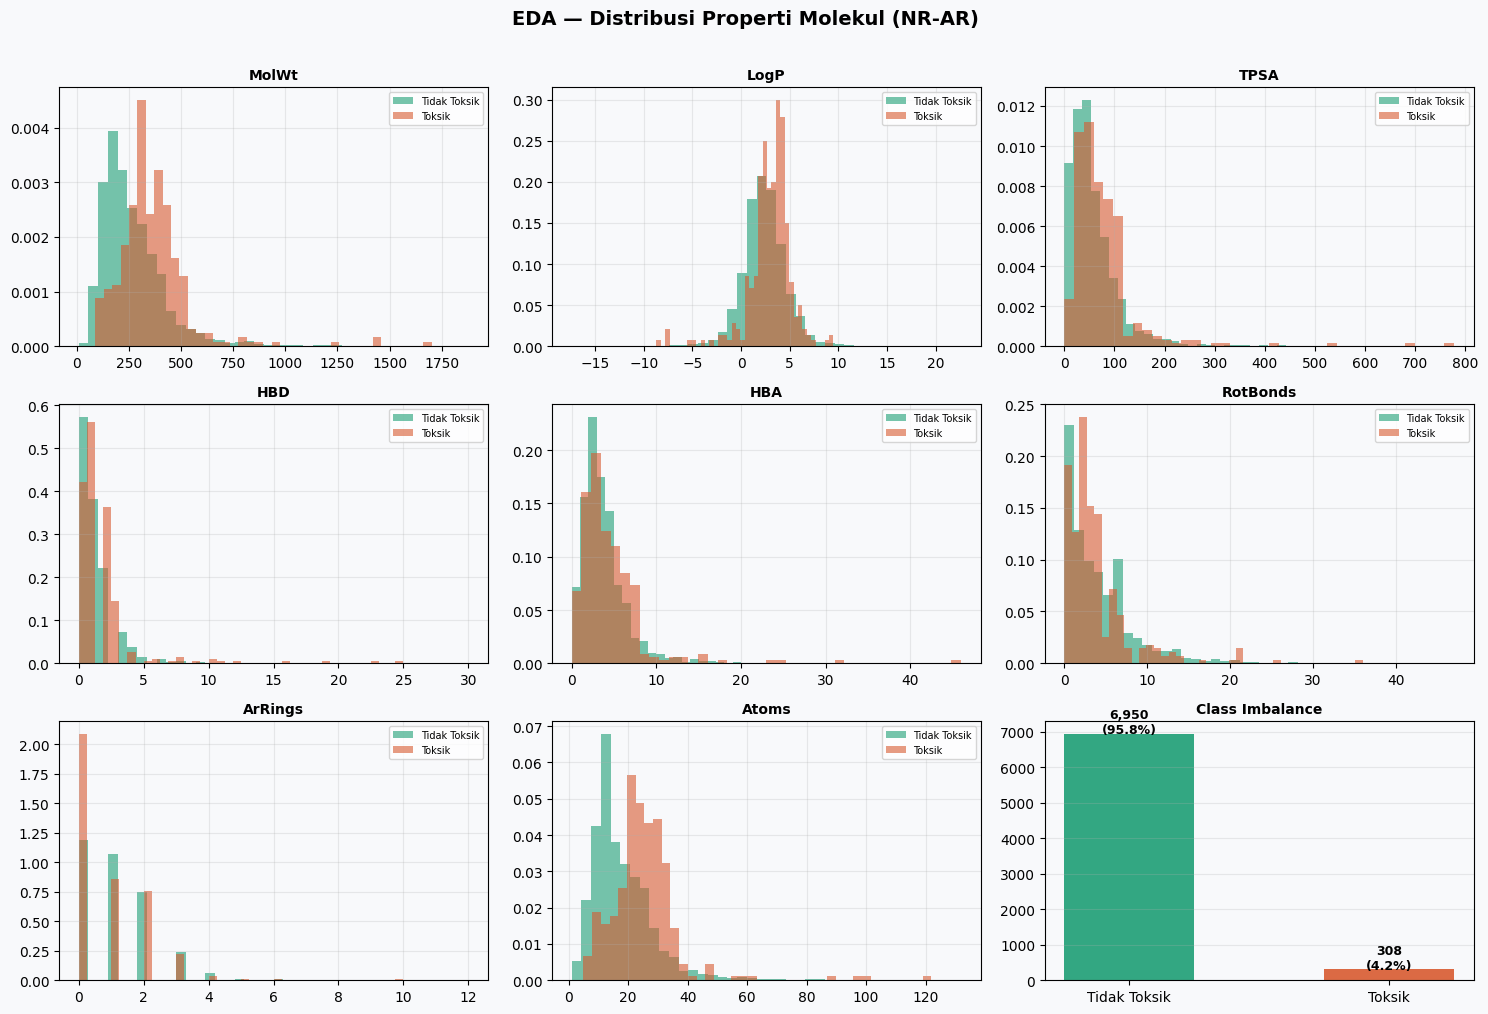

✅ Total NR-AR: 7,258 | Toksik: 308 (4.2%)
        MolWt  LogP   TPSA   HBD   HBA
label                                 
0      270.39  2.37  57.83  1.18  3.38
1      363.62  2.95  77.99  1.74  4.49


In [4]:
def mol_props_df(smiles_list, labels):
    rows = []
    for smi, lbl in zip(smiles_list, labels):
        mol = Chem.MolFromSmiles(smi)
        if mol is None: continue
        rows.append({
            "label": int(lbl),
            "MolWt":   Descriptors.MolWt(mol),
            "LogP":    Descriptors.MolLogP(mol),
            "HBD":     Descriptors.NumHDonors(mol),
            "HBA":     Descriptors.NumHAcceptors(mol),
            "TPSA":    Descriptors.TPSA(mol),
            "RotBonds":Descriptors.NumRotatableBonds(mol),
            "ArRings": Descriptors.NumAromaticRings(mol),
            "Atoms":   mol.GetNumAtoms(),
        })
    return pd.DataFrame(rows)

src_eda = df_clean[["smiles","NR-AR"]].dropna().copy()
src_eda["NR-AR"] = src_eda["NR-AR"].astype(int)
df_eda  = mol_props_df(src_eda.smiles.tolist(), src_eda["NR-AR"].tolist())

CLR = {0:"#1D9E75", 1:"#D85A30"}
LBL = {0:"Tidak Toksik", 1:"Toksik"}

fig, axes = plt.subplots(3, 3, figsize=(15, 10),
                          facecolor="#F8F9FB")
fig.suptitle("EDA — Distribusi Properti Molekul (NR-AR)",
             fontsize=14, fontweight="bold", y=1.01)

props = ["MolWt","LogP","TPSA","HBD","HBA","RotBonds","ArRings","Atoms"]
for ax, col in zip(axes.flat[:8], props):
    for lbl in [0,1]:
        ax.hist(df_eda[df_eda.label==lbl][col],
                bins=40, alpha=0.6, color=CLR[lbl],
                label=LBL[lbl], density=True)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7); ax.grid(alpha=0.25); ax.set_facecolor("#F8F9FB")

ax_last = axes.flat[8]
cc = df_eda.label.value_counts().sort_index()
bars = ax_last.bar(["Tidak Toksik","Toksik"], cc.values,
                    color=["#1D9E75","#D85A30"], alpha=0.9, width=0.5)
for b, v in zip(bars, cc.values):
    ax_last.text(b.get_x()+b.get_width()/2, b.get_height()+5,
                 f"{v:,}\n({v/cc.sum()*100:.1f}%)",
                 ha="center", fontsize=9, fontweight="bold")
ax_last.set_title("Class Imbalance", fontsize=10, fontweight="bold")
ax_last.set_facecolor("#F8F9FB"); ax_last.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("eda_distribution.png", dpi=130, bbox_inches="tight",
            facecolor="#F8F9FB")
plt.show()
print(f"✅ Total NR-AR: {len(df_eda):,} | Toksik: {df_eda.label.sum()} ({df_eda.label.mean()*100:.1f}%)")
print(df_eda.groupby("label")[["MolWt","LogP","TPSA","HBD","HBA"]].mean().round(2))


---
## B4 — Feature Engineering + Seleksi Korelasi

**Fix v4:** korelasi dihitung dari random sample (bukan [:1000]).

Descriptor awal: 52
Dropped (r>0.95): 14 → ['Kappa1', 'Chi0', 'Chi1', 'Chi0n', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v', 'LabuteASA']
Descriptor tersisa: 38
Total fitur/senyawa: 2048 (Morgan) + 38 = 2086


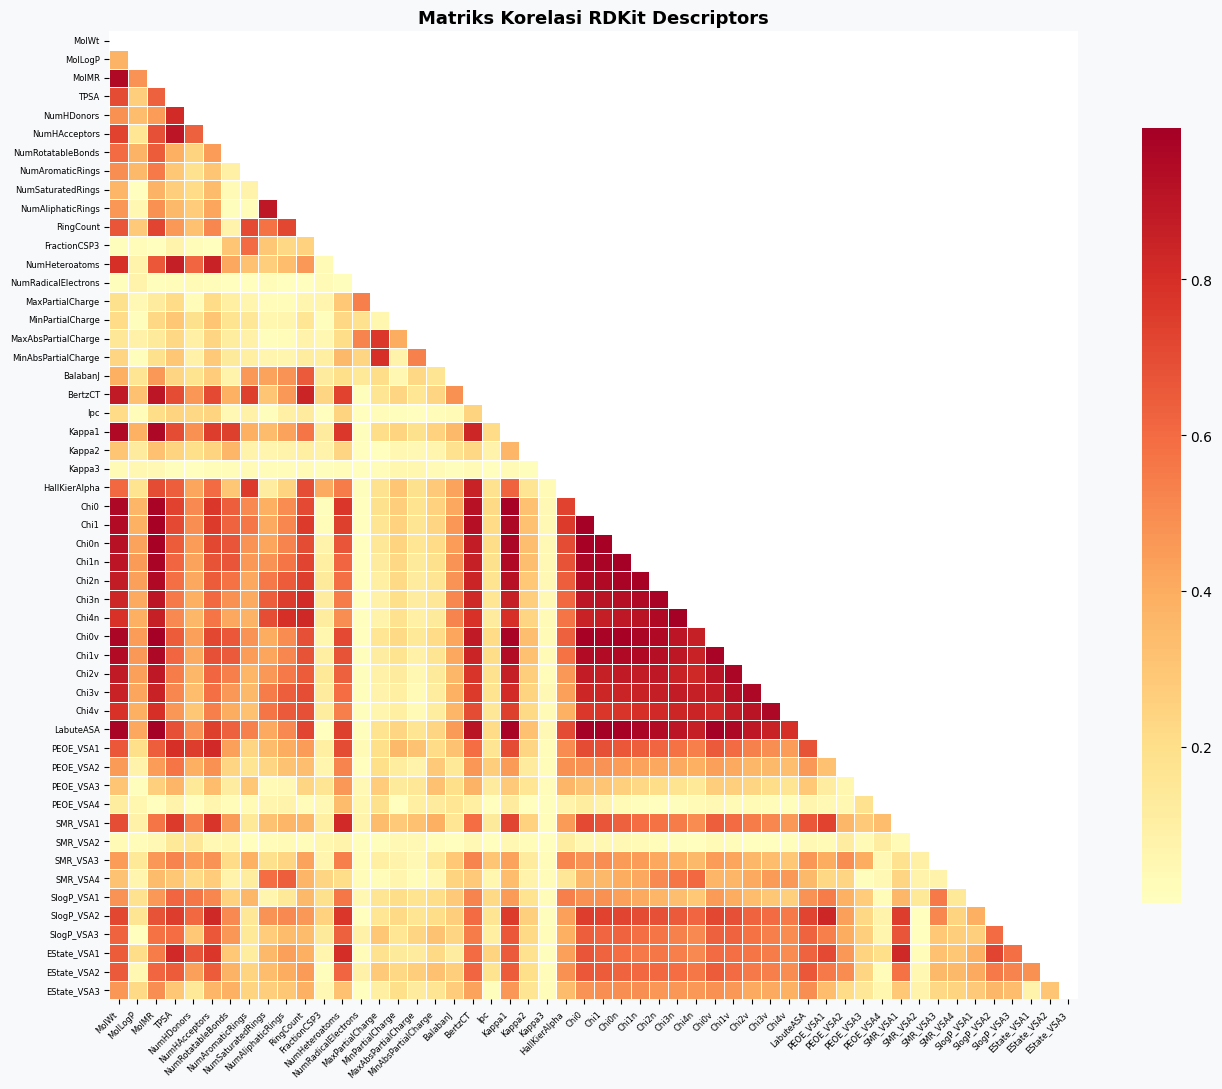

In [5]:
from sklearn.feature_selection import VarianceThreshold

RDKIT_RAW = [
    "MolWt","MolLogP","MolMR","TPSA","NumHDonors","NumHAcceptors",
    "NumRotatableBonds","NumAromaticRings","NumSaturatedRings",
    "NumAliphaticRings","RingCount","FractionCSP3",
    "NumHeteroatoms","NumRadicalElectrons",
    "MaxPartialCharge","MinPartialCharge",
    "MaxAbsPartialCharge","MinAbsPartialCharge",
    "BalabanJ","BertzCT","Ipc","Kappa1","Kappa2","Kappa3",
    "HallKierAlpha","Chi0","Chi1","Chi0n","Chi1n","Chi2n",
    "Chi3n","Chi4n","Chi0v","Chi1v","Chi2v","Chi3v","Chi4v",
    "LabuteASA","PEOE_VSA1","PEOE_VSA2","PEOE_VSA3","PEOE_VSA4",
    "SMR_VSA1","SMR_VSA2","SMR_VSA3","SMR_VSA4",
    "SlogP_VSA1","SlogP_VSA2","SlogP_VSA3",
    "EState_VSA1","EState_VSA2","EState_VSA3",
]
_fn_map   = dict(Descriptors.descList)
DESC_FUNCS = [(n, _fn_map[n]) for n in RDKIT_RAW if n in _fn_map]
DESC_NAMES = [n for n,_ in DESC_FUNCS]
print(f"Descriptor awal: {len(DESC_NAMES)}")

def calc_desc(smi, funcs=DESC_FUNCS):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    vals = []
    for _, fn in funcs:
        try: vals.append(float(fn(mol) or 0.0))
        except: vals.append(0.0)
    return np.array(vals, dtype=np.float32)

def calc_morgan(smi, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    fp  = AllChem.GetMorganFingerprintAsBitVect(mol, radius, n_bits)
    arr = np.zeros(n_bits, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# ── Seleksi korelasi dari RANDOM sample (FIX v4) ──────────────────
rng_sample = df_clean["smiles"].sample(min(1500, len(df_clean)), random_state=42)
desc_sample = []
for smi in rng_sample:
    d = calc_desc(smi)
    if d is not None: desc_sample.append(d)
desc_sample = np.nan_to_num(np.array(desc_sample), nan=0, posinf=0, neginf=0)

df_corr  = pd.DataFrame(desc_sample, columns=DESC_NAMES)
corr_mat = df_corr.corr().abs()
upper    = corr_mat.where(np.triu(np.ones_like(corr_mat, dtype=bool), k=1))
to_drop  = [c for c in upper.columns if (upper[c] > 0.95).any()]
DESC_NAMES_SEL  = [n for n in DESC_NAMES if n not in to_drop]
DESC_FUNCS_SEL  = [(n,fn) for n,fn in DESC_FUNCS if n not in to_drop]

print(f"Dropped (r>0.95): {len(to_drop)} → {to_drop}")
print(f"Descriptor tersisa: {len(DESC_NAMES_SEL)}")
print(f"Total fitur/senyawa: 2048 (Morgan) + {len(DESC_NAMES_SEL)} = {2048+len(DESC_NAMES_SEL)}")

# ── Heatmap ────────────────────────────────────────────────────────
plt.figure(figsize=(14,11), facecolor="#F8F9FB")
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, cmap="RdYlGn_r", center=0,
            square=True, linewidths=.4, cbar_kws={"shrink":.8},
            xticklabels=DESC_NAMES, yticklabels=DESC_NAMES)
plt.title("Matriks Korelasi RDKit Descriptors", fontsize=13, fontweight="bold")
plt.xticks(fontsize=6, rotation=45, ha="right")
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=130, bbox_inches="tight")
plt.show()


In [6]:
def calc_desc_sel(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    vals = []
    for _, fn in DESC_FUNCS_SEL:
        try: vals.append(float(fn(mol) or 0.0))
        except: vals.append(0.0)
    return np.array(vals, dtype=np.float32)

def build_features(smiles_list, scaler=None, fit_scaler=False):
    """
    Morgan 2048-bit + descriptor RDKit yang sudah diseleksi.
    Returns: (X, valid_idx_list, scaler)
    """
    if not fit_scaler and scaler is None:
        raise ValueError("Berikan scaler atau set fit_scaler=True")

    fps, descs, vidx = [], [], []
    for i, smi in enumerate(smiles_list):
        fp = calc_morgan(smi)
        dc_val = calc_desc_sel(smi)    # BUKAN 'dc' — tidak konflik!
        if fp is not None and dc_val is not None:
            fps.append(fp); descs.append(dc_val); vidx.append(i)

    X_fp   = np.array(fps, dtype=np.uint8)
    X_desc = np.nan_to_num(np.array(descs), nan=0, posinf=0, neginf=0)

    if fit_scaler:
        scaler = StandardScaler()
        X_desc_sc = scaler.fit_transform(X_desc)
    else:
        X_desc_sc = scaler.transform(X_desc)

    return np.hstack([X_fp, X_desc_sc]).astype(np.float32), vidx, scaler

print("✅ build_features siap — tidak ada collision variabel 'dc'")


✅ build_features siap — tidak ada collision variabel 'dc'


---
## B5 — SMOTE + 5-Fold StratifiedKFold CV

**Fix v4:**
- `valid_idx` disimpan sebagai `valid_idx_feat` agar tidak ditimpa GNN loop
- SMOTE: pilih satu strategi — tidak double-weight dengan `scale_pos_weight`
- k_neighbors guard: `max(1, min(5, n_pos-1))` + skip jika n_pos < 2

In [7]:
TARGET_TASK = "NR-AR"
df_task = df_clean[["smiles", TARGET_TASK]].dropna().copy()
df_task[TARGET_TASK] = df_task[TARGET_TASK].astype(int)

smiles_all = df_task.smiles.tolist()
labels_all = df_task[TARGET_TASK].values

print(f"Target      : {TARGET_TASK}")
print(f"Total       : {len(df_task):,}")
print(f"Toksik      : {labels_all.sum()} ({labels_all.mean()*100:.1f}%)")
print(f"Rasio       : 1:{(labels_all==0).sum()//labels_all.sum()}")

X_all, valid_idx_feat, global_scaler = build_features(smiles_all, fit_scaler=True)
# ↑ SIMPAN sebagai valid_idx_FEAT — tidak akan ditimpa loop GNN di B9
y_all = labels_all[valid_idx_feat]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f"\nTrain : {X_train.shape} | Toksik: {y_train.sum()}")
print(f"Test  : {X_test.shape}  | Toksik: {y_test.sum()}")


Target      : NR-AR
Total       : 7,258
Toksik      : 308 (4.2%)
Rasio       : 1:22


[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerator
[14:53:49] DEPRECATION WARNING: please use MorganGenerat


Train : (5806, 2086) | Toksik: 246
Test  : (1452, 2086)  | Toksik: 62


[14:54:19] DEPRECATION WARNING: please use MorganGenerator
[14:54:19] DEPRECATION WARNING: please use MorganGenerator
[14:54:19] DEPRECATION WARNING: please use MorganGenerator
[14:54:19] DEPRECATION WARNING: please use MorganGenerator


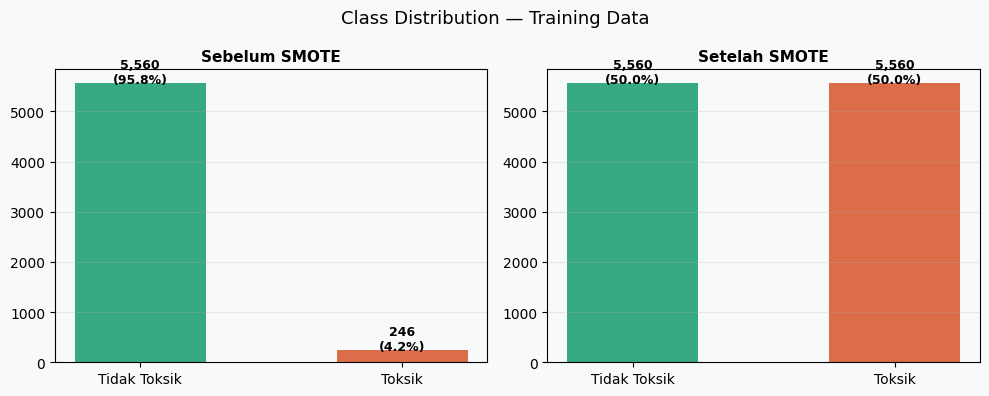

✅ Setelah SMOTE: (11120, 2086) | Toksik: 5560 (50.0%)


In [8]:
# ── SMOTE untuk training final (FIX: scale_pos_weight=1.0 saat SMOTE) ──
n_pos = y_train.sum()
k_nn  = max(1, min(5, int(n_pos) - 1))

if n_pos >= 2:
    smote = SMOTE(random_state=42, k_neighbors=k_nn)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
else:
    print("⚠ Terlalu sedikit positif — skip SMOTE, pakai data asli")
    X_train_sm, y_train_sm = X_train, y_train

fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor="#F8F9FB")
for ax, (y, title) in zip(axes, [(y_train,"Sebelum SMOTE"),(y_train_sm,"Setelah SMOTE")]):
    uniq, cnt = np.unique(y, return_counts=True)
    bars = ax.bar(["Tidak Toksik","Toksik"], cnt,
                  color=["#1D9E75","#D85A30"], alpha=0.88, width=0.5)
    for b, c in zip(bars, cnt):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
                f"{c:,}\n({c/len(y)*100:.1f}%)",
                ha="center", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_facecolor("#F8F9FB"); ax.grid(axis="y", alpha=0.25)
plt.suptitle("Class Distribution — Training Data", fontsize=13)
plt.tight_layout()
plt.savefig("smote_distribution.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"✅ Setelah SMOTE: {X_train_sm.shape} | "
      f"Toksik: {y_train_sm.sum()} ({y_train_sm.mean()*100:.1f}%)")


In [9]:
def cv_with_smote(X, y, model_cls, model_params, n_splits=5, seed=42):
    """
    5-fold StratifiedKFold CV dengan SMOTE per fold.
    FIX v4: scale_pos_weight=1.0 karena SMOTE sudah balance.
    FIX v4: k_neighbors guard untuk kelas positif sedikit.
    """
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        # SMOTE guard
        n_pos_fold = int(y_tr.sum())
        if n_pos_fold >= 2:
            k = max(1, min(5, n_pos_fold - 1))
            X_tr_sm, y_tr_sm = SMOTE(random_state=seed, k_neighbors=k).fit_resample(X_tr, y_tr)
        else:
            X_tr_sm, y_tr_sm = X_tr, y_tr  # skip SMOTE

        mdl = model_cls(**model_params)
        mdl.fit(X_tr_sm, y_tr_sm)
        yp  = mdl.predict_proba(X_val)[:, 1]
        ypb = (yp >= 0.5).astype(int)

        rows.append({
            "fold":    fold+1,
            "roc_auc": roc_auc_score(y_val, yp),
            "f1":      f1_score(y_val, ypb, zero_division=0),
            "mcc":     matthews_corrcoef(y_val, ypb),
            "ap":      average_precision_score(y_val, yp),
        })
        print(f"  Fold {fold+1}: AUC={rows[-1]['roc_auc']:.3f}  "
              f"F1={rows[-1]['f1']:.3f}  MCC={rows[-1]['mcc']:.3f}")
    return pd.DataFrame(rows)

# FIX v4: scale_pos_weight=1.0 karena SMOTE sudah balance data
xgb_params = dict(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=1.0,  # SMOTE sudah balance — tidak double-weight
    eval_metric="auc", random_state=42, verbosity=0
)
print(f"=== 5-Fold StratifiedKFold CV — XGBoost ({TARGET_TASK}) ===\n")
cv_results = cv_with_smote(X_train, y_train, xgb.XGBClassifier, xgb_params)


=== 5-Fold StratifiedKFold CV — XGBoost (NR-AR) ===

  Fold 1: AUC=0.706  F1=0.519  MCC=0.530
  Fold 2: AUC=0.877  F1=0.667  MCC=0.680
  Fold 3: AUC=0.776  F1=0.575  MCC=0.602
  Fold 4: AUC=0.814  F1=0.575  MCC=0.576
  Fold 5: AUC=0.843  F1=0.623  MCC=0.637



=== CV Summary — 95% Confidence Interval ===
  ROC_AUC : 0.8031 ± 0.0294  95%CI [0.7215, 0.8847]
  F1      : 0.5920 ± 0.0249  95%CI [0.5229, 0.6611]
  MCC     : 0.6052 ± 0.0256  95%CI [0.5342, 0.6762]
  AP      : 0.5329 ± 0.0365  95%CI [0.4316, 0.6342]


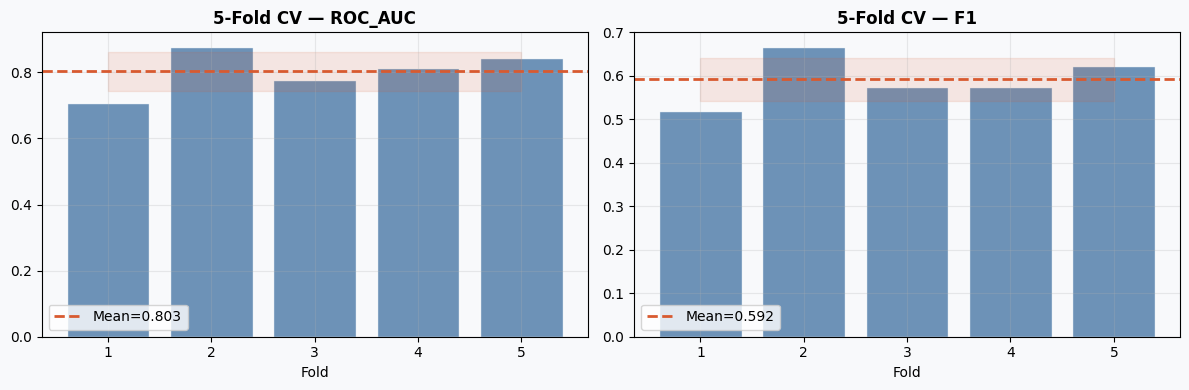

In [10]:
print("\n=== CV Summary — 95% Confidence Interval ===")
for m in ["roc_auc","f1","mcc","ap"]:
    vals = cv_results[m].values
    mean = np.mean(vals); se = stats.sem(vals)
    ci   = stats.t.interval(0.95, len(vals)-1, loc=mean, scale=se)
    print(f"  {m.upper():8s}: {mean:.4f} ± {se:.4f}  "
          f"95%CI [{ci[0]:.4f}, {ci[1]:.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="#F8F9FB")
for ax, m in zip(axes, ["roc_auc","f1"]):
    vals = cv_results[m].values
    bars = ax.bar(range(1,6), vals, color="#5580AC", alpha=0.85, edgecolor="white")
    ax.axhline(np.mean(vals), color="#D85A30", lw=2, ls="--",
               label=f"Mean={np.mean(vals):.3f}")
    ax.fill_between(range(1,6),
                    np.mean(vals)-np.std(vals),
                    np.mean(vals)+np.std(vals),
                    alpha=0.12, color="#D85A30")
    ax.set_title(f"5-Fold CV — {m.upper()}", fontweight="bold")
    ax.set_xlabel("Fold"); ax.legend(); ax.grid(alpha=0.25)
    ax.set_facecolor("#F8F9FB")
plt.tight_layout()
plt.savefig("cv_results.png", dpi=130, bbox_inches="tight")
plt.show()


---
## B6 — Training Final + Threshold Optimization

In [11]:
print("=== Training Final (XGBoost + RF) ===\n")
# FIX v4: RF tanpa class_weight='balanced' — SMOTE sudah balance
models_def = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, n_jobs=-1, random_state=42  # tidak double-weight
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=1.0, eval_metric="auc",
        random_state=42, verbosity=0
    ),
}

trained  = {}
results  = {}
for name, mdl in models_def.items():
    mdl.fit(X_train_sm, y_train_sm)
    yp   = mdl.predict_proba(X_test)[:, 1]
    ypb  = (yp >= 0.5).astype(int)
    results[name] = {
        "ROC-AUC": roc_auc_score(y_test, yp),
        "F1":      f1_score(y_test, ypb, zero_division=0),
        "MCC":     matthews_corrcoef(y_test, ypb),
        "AP":      average_precision_score(y_test, yp),
    }
    trained[name] = mdl
    print(f"{name}:")
    for k,v in results[name].items(): print(f"  {k}: {v:.4f}")
    print()

df_res      = pd.DataFrame(results).T.round(4)
best_model  = trained[df_res["ROC-AUC"].idxmax()]
print("Model terbaik:", df_res["ROC-AUC"].idxmax())
print(df_res)


=== Training Final (XGBoost + RF) ===

Random Forest:
  ROC-AUC: 0.7505
  F1: 0.5333
  MCC: 0.5649
  AP: 0.4747

XGBoost:
  ROC-AUC: 0.7246
  F1: 0.5161
  MCC: 0.5344
  AP: 0.4522

Model terbaik: Random Forest
               ROC-AUC      F1     MCC      AP
Random Forest   0.7505  0.5333  0.5649  0.4747
XGBoost         0.7246  0.5161  0.5344  0.4522


Threshold 0.50  : F1=0.5161
Threshold 0.899 : F1=0.5455  Prec=0.9231  Rec=0.3871

              precision    recall  f1-score   support

Tidak Toksik       0.97      1.00      0.99      1390
      Toksik       0.92      0.39      0.55        62

    accuracy                           0.97      1452
   macro avg       0.95      0.69      0.77      1452
weighted avg       0.97      0.97      0.97      1452



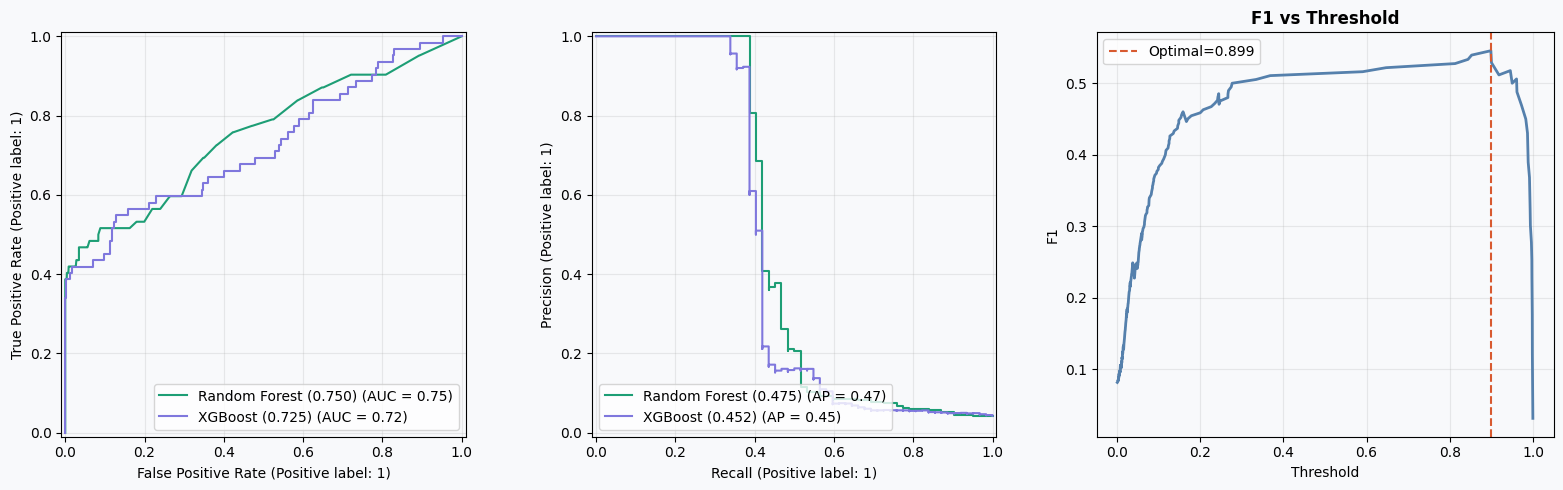

✅ Model NR-AR tersimpan.


In [12]:
# ── Threshold Optimization via F1-PR curve ──────────────────────────
y_prob_xgb = trained["XGBoost"].predict_proba(X_test)[:, 1]
pr_p, pr_r, pr_th = precision_recall_curve(y_test, y_prob_xgb)
f1_arr = 2*(pr_p[:-1]*pr_r[:-1])/(pr_p[:-1]+pr_r[:-1]+1e-8)
opt_i  = np.argmax(f1_arr)
OPTIMAL_THRESH = float(pr_th[opt_i])

print(f"Threshold 0.50  : F1={f1_score(y_test,(y_prob_xgb>=0.50).astype(int),zero_division=0):.4f}")
print(f"Threshold {OPTIMAL_THRESH:.3f} : F1={f1_arr[opt_i]:.4f}  "
      f"Prec={pr_p[opt_i]:.4f}  Rec={pr_r[opt_i]:.4f}")
print(f"\n{classification_report(y_test,(y_prob_xgb>=OPTIMAL_THRESH).astype(int),target_names=['Tidak Toksik','Toksik'])}")

# ── Plot 3 panel ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#F8F9FB")
CLR_M = {"Random Forest":"#1D9E75","XGBoost":"#7F77DD"}
for nm, mdl in trained.items():
    yp = mdl.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(
        y_test, yp, name=f"{nm} ({roc_auc_score(y_test,yp):.3f})",
        ax=axes[0], color=CLR_M[nm])
    PrecisionRecallDisplay.from_predictions(
        y_test, yp, name=f"{nm} ({average_precision_score(y_test,yp):.3f})",
        ax=axes[1], color=CLR_M[nm])
for ax in axes[:2]: ax.grid(alpha=0.25); ax.set_facecolor("#F8F9FB")
axes[2].plot(pr_th, f1_arr, "#5580AC", lw=2)
axes[2].axvline(OPTIMAL_THRESH, color="#D85A30", ls="--",
                label=f"Optimal={OPTIMAL_THRESH:.3f}")
axes[2].set_xlabel("Threshold"); axes[2].set_ylabel("F1")
axes[2].set_title("F1 vs Threshold", fontweight="bold")
axes[2].legend(); axes[2].grid(alpha=0.25); axes[2].set_facecolor("#F8F9FB")
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Simpan model NR-AR ───────────────────────────────────────────────
os.makedirs("saved_models", exist_ok=True)
joblib.dump(trained["XGBoost"],   "saved_models/NR-AR_xgboost.pkl")
joblib.dump(global_scaler,         "saved_models/NR-AR_scaler.pkl")
joblib.dump(DESC_NAMES_SEL,        "saved_models/NR-AR_desc_names.pkl")
with open("saved_models/NR-AR_meta.json","w") as f:
    json.dump({"target":TARGET_TASK,"threshold":OPTIMAL_THRESH,
               "n_desc":len(DESC_NAMES_SEL)},f,indent=2)
print("✅ Model NR-AR tersimpan.")


---
## B7 — Multi-Task Learning: 12 Target Tox21

**Fix v4:**
- Variabel descriptor dinamai `rdkd` (bukan `dc`) — tidak ada collision
- Y_mt matrix diisi dengan vectorized merge (bukan nested loop O(n²))
- `scale_pos_weight` per-target dari data asli; SMOTE tetap dipakai + spw berbeda untuk sinyal lebih kuat

In [13]:
from sklearn.multioutput import MultiOutputClassifier

# ── Filter target yang cukup data ──────────────────────────────────
valid_tasks = [t for t in TOX21_TASKS
               if df_clean[t].notna().sum() > 0 and df_clean[t].sum(skipna=True) >= 20]
print(f"Target valid: {len(valid_tasks)}/12 → {valid_tasks}\n")

# ── Build feature matrix (FIX: pakai 'rdkd', bukan 'dc') ──────────
print("Membangun feature matrix multi-task...")
X_mt_fp, X_mt_desc_raw, smiles_mt = [], [], []
for smi in df_clean.smiles.tolist():
    fp   = calc_morgan(smi)
    rdkd = calc_desc_sel(smi)     # ← FIX: bukan 'dc'
    if fp is None or rdkd is None: continue
    smiles_mt.append(smi)
    X_mt_fp.append(fp)
    X_mt_desc_raw.append(rdkd)

X_mt_fp   = np.array(X_mt_fp, dtype=np.uint8)
X_mt_desc = np.nan_to_num(np.array(X_mt_desc_raw), nan=0, posinf=0, neginf=0)
mt_scaler = StandardScaler()
X_mt      = np.hstack([X_mt_fp, mt_scaler.fit_transform(X_mt_desc)]).astype(np.float32)
print(f"X_mt shape: {X_mt.shape}")

# ── Build label matrix — VECTORIZED (FIX: bukan O(n²)) ────────────
print("Mengisi label matrix (vectorized)...")
smi_to_idx = {s: i for i, s in enumerate(smiles_mt)}
Y_mt = np.full((len(smiles_mt), len(valid_tasks)), np.nan)
for j, task in enumerate(valid_tasks):
    df_j = df_clean[["smiles", task]].dropna(subset=[task])
    for _, row in df_j.iterrows():
        idx = smi_to_idx.get(row["smiles"])
        if idx is not None:
            Y_mt[idx, j] = int(row[task])

pct_labeled = (~np.isnan(Y_mt)).mean(axis=0).mean() * 100
print(f"Y_mt shape: {Y_mt.shape}")
print(f"Rata-rata label tersedia: {pct_labeled:.1f}%")


Target valid: 12/12 → ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']

Membangun feature matrix multi-task...


[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerator
[14:55:46] DEPRECATION WARNING: please use MorganGenerat

X_mt shape: (7823, 2086)
Mengisi label matrix (vectorized)...
Y_mt shape: (7823, 12)
Rata-rata label tersedia: 82.9%


In [14]:
print("=== Training Multi-Task XGBoost ===\n")
MT_MODELS     = {}
MT_THRESHOLDS = {}
MT_RESULTS    = {}

for j, task in enumerate(valid_tasks):
    mask = ~np.isnan(Y_mt[:, j])
    X_t  = X_mt[mask]
    y_t  = Y_mt[mask, j].astype(int)
    n_p  = int(y_t.sum())
    n_n  = int((y_t == 0).sum())

    if n_p < 20: continue

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_t, y_t, test_size=0.2, random_state=42, stratify=y_t)

    # SMOTE guard
    k = max(1, min(5, int(y_tr.sum()) - 1))
    if y_tr.sum() >= 2:
        X_tr_sm, y_tr_sm = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr, y_tr)
    else:
        X_tr_sm, y_tr_sm = X_tr, y_tr

    # scale_pos_weight dari data ASLI — sinyal lebih kuat pada target ekstrem
    spw = round(n_n / n_p, 2)
    m   = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                              scale_pos_weight=spw, eval_metric="auc",
                              random_state=42, verbosity=0)
    m.fit(X_tr_sm, y_tr_sm)

    yp = m.predict_proba(X_te)[:, 1]
    pr_p2, pr_r2, pr_th2 = precision_recall_curve(y_te, yp)
    f1_a = 2*(pr_p2[:-1]*pr_r2[:-1])/(pr_p2[:-1]+pr_r2[:-1]+1e-8)
    th   = float(pr_th2[np.argmax(f1_a)]) if len(pr_th2) else 0.5
    ypb  = (yp >= th).astype(int)

    MT_MODELS[task]     = m
    MT_THRESHOLDS[task] = th
    MT_RESULTS[task]    = {
        "AUC": roc_auc_score(y_te, yp),
        "F1":  f1_score(y_te, ypb, zero_division=0),
        "MCC": matthews_corrcoef(y_te, ypb),
        "AP":  average_precision_score(y_te, yp),
        "n_pos": n_p, "n_total": len(y_t),
        "imbalance_ratio": round(n_n/n_p, 1),
        "scale_pos_weight": spw, "threshold": th,
    }
    joblib.dump(m, f"saved_models/mt_{task}_xgb.pkl")
    print(f"  {task:<20} AUC={MT_RESULTS[task]['AUC']:.3f}  "
          f"F1={MT_RESULTS[task]['F1']:.3f}  spw={spw:.1f}  thresh={th:.3f}")

joblib.dump(mt_scaler,    "saved_models/mt_scaler.pkl")
joblib.dump(valid_tasks,  "saved_models/mt_valid_tasks.pkl")
with open("saved_models/mt_thresholds.json","w") as f:
    json.dump(MT_THRESHOLDS, f, indent=2)
print(f"\n✅ {len(MT_MODELS)} model multi-task tersimpan.")


=== Training Multi-Task XGBoost ===

  NR-AR                AUC=0.709  F1=0.545  spw=22.6  thresh=0.971
  NR-AR-LBD            AUC=0.849  F1=0.721  spw=27.5  thresh=0.856
  NR-AhR               AUC=0.897  F1=0.590  spw=7.5  thresh=0.853
  NR-Aromatase         AUC=0.844  F1=0.511  spw=18.4  thresh=0.910
  NR-ER                AUC=0.681  F1=0.394  spw=6.8  thresh=0.732
  NR-ER-LBD            AUC=0.824  F1=0.533  spw=18.9  thresh=0.865
  NR-PPAR-gamma        AUC=0.819  F1=0.400  spw=33.6  thresh=0.914
  SR-ARE               AUC=0.818  F1=0.512  spw=5.2  thresh=0.753
  SR-ATAD5             AUC=0.854  F1=0.424  spw=25.8  thresh=0.901
  SR-HSE               AUC=0.759  F1=0.433  spw=16.4  thresh=0.939
  SR-MMP               AUC=0.919  F1=0.672  spw=5.3  thresh=0.729
  SR-p53               AUC=0.872  F1=0.388  spw=15.0  thresh=0.739

✅ 12 model multi-task tersimpan.


                 AUC     F1    MCC     AP  n_pos  imbalance_ratio  threshold
SR-MMP         0.919  0.672  0.610  0.714  918.0              5.3      0.729
NR-AhR         0.897  0.590  0.542  0.596  768.0              7.5      0.853
SR-p53         0.872  0.388  0.344  0.386  423.0             15.0      0.739
SR-ATAD5       0.854  0.424  0.421  0.405  264.0             25.8      0.901
NR-AR-LBD      0.849  0.721  0.715  0.653  237.0             27.5      0.856
NR-Aromatase   0.844  0.511  0.526  0.510  300.0             18.4      0.910
NR-ER-LBD      0.824  0.533  0.521  0.473  349.0             18.9      0.865
NR-PPAR-gamma  0.819  0.400  0.415  0.300  186.0             33.6      0.914
SR-ARE         0.818  0.512  0.423  0.523  942.0              5.2      0.753
SR-HSE         0.759  0.433  0.496  0.392  372.0             16.4      0.939
NR-AR          0.709  0.545  0.588  0.447  308.0             22.6      0.971
NR-ER          0.681  0.394  0.307  0.408  791.0              6.8      0.732

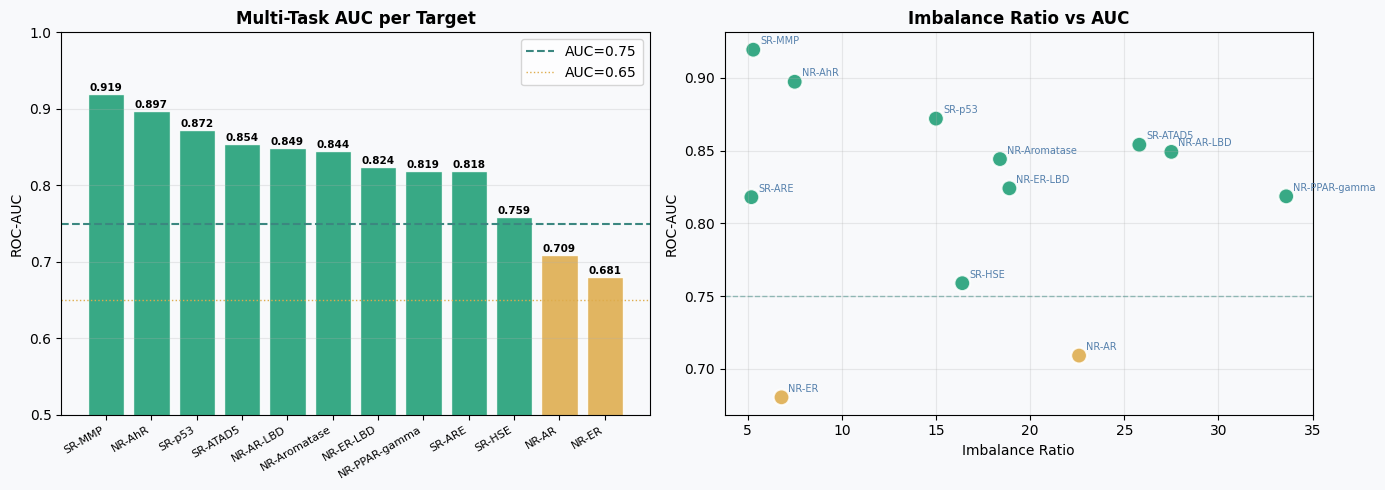

In [15]:
df_mt = pd.DataFrame(MT_RESULTS).T.sort_values("AUC", ascending=False)
print(df_mt[["AUC","F1","MCC","AP","n_pos","imbalance_ratio","threshold"]].round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#F8F9FB")
cmap = ["#D85A30" if v<0.65 else "#DEAC4C" if v<0.75 else "#1D9E75"
        for v in df_mt.AUC]
bars = axes[0].bar(df_mt.index, df_mt.AUC, color=cmap, alpha=0.88, edgecolor="white")
axes[0].axhline(0.75, color="#3B8780", lw=1.5, ls="--", label="AUC=0.75")
axes[0].axhline(0.65, color="#DEAC4C", lw=1,   ls=":",  label="AUC=0.65")
for b, v in zip(bars, df_mt.AUC):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+.004,
                 f"{v:.3f}", ha="center", fontsize=7.5, fontweight="bold")
axes[0].set_ylim(0.5, 1.0); axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("Multi-Task AUC per Target", fontweight="bold")
axes[0].legend(); axes[0].grid(axis="y",alpha=0.25)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right", fontsize=8)

axes[1].scatter(df_mt.imbalance_ratio, df_mt.AUC, c=cmap, s=130,
                alpha=0.88, edgecolors="white", lw=1.5)
for idx, row in df_mt.iterrows():
    axes[1].annotate(idx,(row.imbalance_ratio,row.AUC),
                     xytext=(5,4), textcoords="offset points",
                     fontsize=7, color="#5580AC")
axes[1].axhline(0.75, color="#3B8780", lw=1, ls="--", alpha=0.5)
axes[1].set_xlabel("Imbalance Ratio"); axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Imbalance Ratio vs AUC", fontweight="bold")
axes[1].grid(alpha=0.25)
for ax in axes: ax.set_facecolor("#F8F9FB")
plt.tight_layout()
plt.savefig("multitask_analysis.png", dpi=130, bbox_inches="tight")
plt.show()


---
## B8 — GNN AttentiveFP Multi-Task (PyG)

**Fix v4:**
- Split stratified via `train_test_split` (bukan slicing biasa)
- Satu definisi model `gnn_model` dengan alias eksplisit
- Assert shape check sebelum training

In [16]:
# ── Load dataset PyG ─────────────────────────────────────────────────
torch.manual_seed(42); np.random.seed(42)

dataset_pyg = MoleculeNet(root="/tmp/tox21_pyg", name="Tox21")
n_total     = len(dataset_pyg)
print(f"Dataset PyG Tox21: {n_total} molekul")

# FIX v4: Stratified split (proxy label NR-AR, index 0)
y_proxy = np.array([
    float(dataset_pyg[i].y[0, 0].item()) for i in range(n_total)
])
y_proxy_bin = (y_proxy > 0.5).astype(int)
y_proxy_bin[np.isnan(y_proxy)] = 0

all_idx = np.arange(n_total)
train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.30, random_state=42, stratify=y_proxy_bin)
val_idx, test_idx   = train_test_split(
    temp_idx, test_size=0.667, random_state=42, stratify=y_proxy_bin[temp_idx])

device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(dataset_pyg[train_idx.tolist()], batch_size=64, shuffle=True)
valid_loader = DataLoader(dataset_pyg[val_idx.tolist()],   batch_size=64)
test_loader  = DataLoader(dataset_pyg[test_idx.tolist()],  batch_size=64)

# Verifikasi dimensi
sample_batch = next(iter(train_loader))
IN_CH  = sample_batch.x.shape[1]
ED_DIM = sample_batch.edge_attr.shape[1] if sample_batch.edge_attr is not None else 0
print(f"Train/Val/Test: {len(train_idx)}/{len(val_idx)}/{len(test_idx)}")
print(f"Atom features  : {IN_CH}")
print(f"Edge features  : {ED_DIM}")
print(f"Label columns  : {sample_batch.y.shape[1]}")
print(f"Device         : {device}")


Dataset PyG Tox21: 7823 molekul
Train/Val/Test: 5476/781/1566
Atom features  : 9
Edge features  : 3
Label columns  : 12
Device         : cpu


In [17]:
# ── Model AttentiveFP Multi-Task (FIX: satu definisi, alias gnn_model) ──
class AttentiveFPMultiTask(nn.Module):
    def __init__(self, n_tasks, in_ch, edge_dim,
                 hidden=200, n_layers=3, n_ts=2, dropout=0.2):
        super().__init__()
        self.gnn  = AttentiveFP(
            in_channels=in_ch, hidden_channels=hidden,
            out_channels=hidden, edge_dim=edge_dim,
            num_layers=n_layers, num_timesteps=n_ts, dropout=dropout)
        self.head = nn.Linear(hidden, n_tasks)

    def forward(self, data):
        x = self.gnn(data.x.float(), data.edge_index,
                     data.edge_attr.float() if data.edge_attr is not None else None,
                     data.batch)
        return torch.sigmoid(self.head(x))

N_TASKS   = sample_batch.y.shape[1]   # pakai jumlah label aktual dari dataset
gnn_model = AttentiveFPMultiTask(
    n_tasks=N_TASKS, in_ch=IN_CH, edge_dim=ED_DIM
).to(device)

# Assert shape sebelum training
with torch.no_grad():
    out_test = gnn_model(sample_batch.to(device))
assert out_test.shape[1] == N_TASKS, f"Output {out_test.shape[1]} != {N_TASKS}"
print(f"✅ gnn_model: output shape {out_test.shape} (n_tasks={N_TASKS})")

optimizer = torch.optim.Adam(gnn_model.parameters(), lr=1e-3)
print(f"   hidden=200, layers=3, timesteps=2, dropout=0.2")


✅ gnn_model: output shape torch.Size([64, 12]) (n_tasks=12)
   hidden=200, layers=3, timesteps=2, dropout=0.2


In [18]:
def train_epoch_gnn(loader):
    gnn_model.train()
    total = 0
    for batch in loader:
        batch = batch.to(device)
        pred  = gnn_model(batch)
        y     = batch.y.float()
        mask  = ~torch.isnan(y)
        y_c   = torch.where(mask, y, torch.zeros_like(y))
        loss  = (nn.BCELoss(reduction="none")(pred, y_c) * mask.float()
                 ).sum() / mask.float().sum().clamp(min=1)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item()
    return total / len(loader)

def eval_auc_gnn(loader):
    gnn_model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            preds.append(gnn_model(batch).cpu().numpy())
            tgts.append(batch.y.cpu().numpy())
    preds = np.vstack(preds); tgts = np.vstack(tgts)
    aucs  = []
    for j in range(tgts.shape[1]):
        mask_j = ~np.isnan(tgts[:, j])
        if mask_j.sum() > 10 and len(np.unique(tgts[mask_j, j])) > 1:
            try: aucs.append(roc_auc_score(tgts[mask_j, j], preds[mask_j, j]))
            except: pass
    return np.mean(aucs) if aucs else 0.5, preds, tgts

# ── Training loop ────────────────────────────────────────────────────
os.makedirs("saved_models", exist_ok=True)
N_EPOCH_GNN = 30
GNN_LOSSES, GNN_AUCS = [], []
best_gnn_auc, best_gnn_ep = 0, 0

print(f"=== Training GNN ({N_EPOCH_GNN} epoch, device={device}) ===\n")
for ep in range(N_EPOCH_GNN):
    loss = train_epoch_gnn(train_loader)
    auc, _, _ = eval_auc_gnn(valid_loader)
    GNN_LOSSES.append(loss); GNN_AUCS.append(auc)
    if auc > best_gnn_auc:
        best_gnn_auc = auc; best_gnn_ep = ep+1
        torch.save(gnn_model.state_dict(), "saved_models/best_gnn.pt")
    if (ep+1) % 5 == 0:
        print(f"  Epoch {ep+1:3d}/{N_EPOCH_GNN}: loss={loss:.4f}  valid_AUC={auc:.4f}")

print(f"\n✅ Best valid AUC={best_gnn_auc:.4f} (epoch {best_gnn_ep})")
# Load best weights
gnn_model.load_state_dict(torch.load("saved_models/best_gnn.pt", map_location=device))


=== Training GNN (30 epoch, device=cpu) ===

  Epoch   5/30: loss=0.2257  valid_AUC=0.7502
  Epoch  10/30: loss=0.2168  valid_AUC=0.7734
  Epoch  15/30: loss=0.2088  valid_AUC=0.7975
  Epoch  20/30: loss=0.2016  valid_AUC=0.8015
  Epoch  25/30: loss=0.1969  valid_AUC=0.8064
  Epoch  30/30: loss=0.1897  valid_AUC=0.8189

✅ Best valid AUC=0.8196 (epoch 29)


<All keys matched successfully>

=== Evaluasi GNN pada Test Set ===

Target                    AUC      F1     MCC      AP   thresh
──────────────────────────────────────────────────────────
  NR-AR                 0.839   0.589   0.603   0.514    0.218
  NR-AR-LBD             0.892   0.627   0.635   0.556    0.447
  NR-AhR                0.868   0.518   0.448   0.501    0.195
  NR-Aromatase          0.828   0.294   0.258   0.217    0.164
  NR-ER                 0.705   0.431   0.321   0.388    0.125
  NR-ER-LBD             0.812   0.427   0.395   0.355    0.250
  NR-PPAR-gamma         0.813   0.250   0.242   0.148    0.086
  SR-ARE                0.811   0.515   0.413   0.490    0.223
  SR-ATAD5              0.841   0.333   0.306   0.213    0.114
  SR-HSE                0.773   0.366   0.330   0.291    0.135
  SR-MMP                0.888   0.665   0.605   0.669    0.447
  SR-p53                0.817   0.357   0.312   0.284    0.130

✅ GNN NR-AR: AUC=0.8391  thresh=0.218


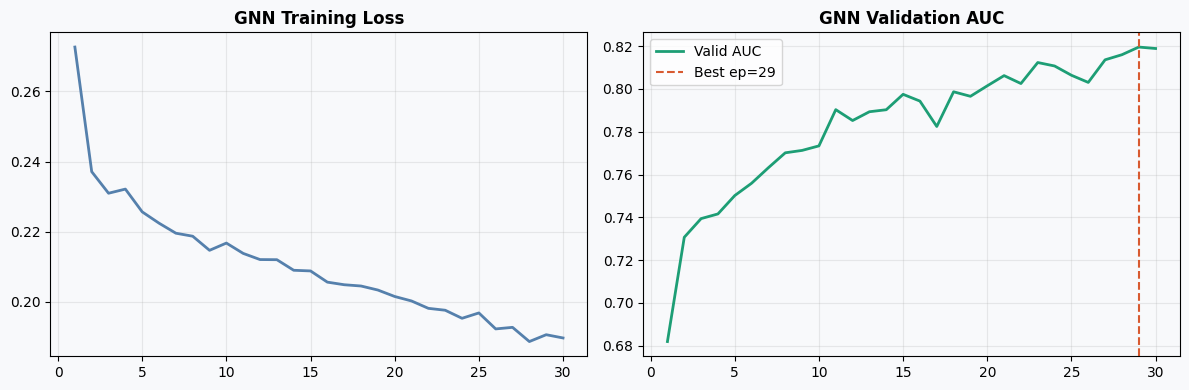

In [19]:
print("=== Evaluasi GNN pada Test Set ===\n")
_, y_prob_gnn_all, y_true_gnn_all = eval_auc_gnn(test_loader)

# FIX v4: gunakan TOX21_TASKS konsisten (bukan task_names/GNN_TASKS redundan)
GNN_MT_RESULTS    = {}
GNN_MT_THRESHOLDS = {}

# Inisialisasi default (FIX v4: agar tidak NameError jika NR-AR skip)
gnn_auc = gnn_f1 = gnn_mcc = gnn_ap = 0.5
thresh_gnn = 0.5

print(f"{'Target':<20} {'AUC':>8} {'F1':>7} {'MCC':>7} {'AP':>7} {'thresh':>8}")
print("─" * 58)
for j, task in enumerate(TOX21_TASKS):
    if j >= y_true_gnn_all.shape[1]: continue
    mask = ~np.isnan(y_true_gnn_all[:, j])
    if mask.sum() < 10 or len(np.unique(y_true_gnn_all[mask, j])) < 2:
        print(f"  {task:<18} SKIP"); continue
    yp_j = y_prob_gnn_all[mask, j]
    yt_j = np.round(y_true_gnn_all[mask, j]).astype(int)
    pr_p3, pr_r3, pr_th3 = precision_recall_curve(yt_j, yp_j)
    f1_a3 = 2*(pr_p3[:-1]*pr_r3[:-1])/(pr_p3[:-1]+pr_r3[:-1]+1e-8)
    th3   = float(pr_th3[np.argmax(f1_a3)]) if len(pr_th3) else 0.5
    ypb3  = (yp_j >= th3).astype(int)
    auc3  = roc_auc_score(yt_j, yp_j)
    f1_3  = f1_score(yt_j, ypb3, zero_division=0)
    mcc3  = matthews_corrcoef(yt_j, ypb3)
    ap3   = average_precision_score(yt_j, yp_j)
    GNN_MT_RESULTS[task]    = {"AUC":auc3,"F1":f1_3,"MCC":mcc3,"AP":ap3}
    GNN_MT_THRESHOLDS[task] = th3
    if task == "NR-AR":
        gnn_auc = auc3; gnn_f1 = f1_3; gnn_mcc = mcc3
        gnn_ap  = ap3;  thresh_gnn = th3
    print(f"  {task:<18} {auc3:>8.3f} {f1_3:>7.3f} {mcc3:>7.3f} {ap3:>7.3f} {th3:>8.3f}")

print(f"\n✅ GNN NR-AR: AUC={gnn_auc:.4f}  thresh={thresh_gnn:.3f}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12,4), facecolor="#F8F9FB")
axes[0].plot(range(1,N_EPOCH_GNN+1), GNN_LOSSES, "#5580AC", lw=2)
axes[0].set_title("GNN Training Loss", fontweight="bold"); axes[0].grid(alpha=0.25)
axes[1].plot(range(1,N_EPOCH_GNN+1), GNN_AUCS, "#1D9E75", lw=2, label="Valid AUC")
axes[1].axvline(best_gnn_ep, color="#D85A30", ls="--", lw=1.5, label=f"Best ep={best_gnn_ep}")
axes[1].set_title("GNN Validation AUC", fontweight="bold"); axes[1].legend(); axes[1].grid(alpha=0.25)
for ax in axes: ax.set_facecolor("#F8F9FB")
plt.tight_layout()
plt.savefig("gnn_training_curves.png", dpi=130, bbox_inches="tight"); plt.show()


---
## B9 — GNN 5-Fold StratifiedKFold CV

**Fix v4:**
- `StratifiedKFold` (bukan `KFold`) dengan label proxy NR-AR
- Loop variable `val_fold_idx` (bukan `valid_idx`) — tidak menimpa `valid_idx_feat`
- Simpan AUC per-target → perbandingan B10 apple-to-apple

In [20]:
from sklearn.model_selection import StratifiedKFold

print("=== B9: GNN 5-Fold StratifiedKFold CV ===\n")

# Dataset train+val untuk CV (test tetap held-out)
cv_indices = list(range(len(train_idx) + len(val_idx)))
dataset_cv = dataset_pyg[(np.concatenate([train_idx, val_idx])).tolist()]

# Label proxy NR-AR untuk stratifikasi
y_cv_proxy = np.array([
    float(dataset_cv[i].y[0, 0].item()) for i in range(len(dataset_cv))
])
y_cv_bin = (y_cv_proxy > 0.5).astype(int)
y_cv_bin[np.isnan(y_cv_proxy)] = 0

N_FOLDS_GNN = 5; N_EP_CV = 20   # 20 epoch per fold agar tidak terlalu lama
skf_gnn = StratifiedKFold(n_splits=N_FOLDS_GNN, shuffle=True, random_state=42)

fold_aucs_nrar = []   # hanya NR-AR — untuk perbandingan dengan XGBoost
fold_aucs_mean = []   # mean semua target — untuk info

for fold, (tr_fi, val_fold_idx) in enumerate(skf_gnn.split(cv_indices, y_cv_bin)):
    # FIX v4: nama 'val_fold_idx' — tidak menimpa valid_idx_feat!
    print(f"── Fold {fold+1}/{N_FOLDS_GNN} ──")
    tr_d  = DataLoader(dataset_cv[tr_fi.tolist()],       batch_size=64, shuffle=True)
    val_d = DataLoader(dataset_cv[val_fold_idx.tolist()], batch_size=64)

    fold_model = AttentiveFPMultiTask(n_tasks=N_TASKS, in_ch=IN_CH, edge_dim=ED_DIM).to(device)
    fold_opt   = torch.optim.Adam(fold_model.parameters(), lr=1e-3)
    best_fold_nrar = 0.5

    for ep in range(N_EP_CV):
        # Train
        fold_model.train()
        for batch in tr_d:
            batch = batch.to(device)
            pred  = fold_model(batch)
            y_b   = batch.y.float()
            mask  = ~torch.isnan(y_b)
            y_c   = torch.where(mask, y_b, torch.zeros_like(y_b))
            loss  = (nn.BCELoss(reduction="none")(pred, y_c) * mask.float()
                     ).sum() / mask.float().sum().clamp(min=1)
            fold_opt.zero_grad(); loss.backward(); fold_opt.step()

        # Eval per-target
        fold_model.eval()
        ps, ts = [], []
        with torch.no_grad():
            for batch in val_d:
                batch = batch.to(device)
                ps.append(fold_model(batch).cpu().numpy())
                ts.append(batch.y.cpu().numpy())
        ps = np.vstack(ps); ts = np.vstack(ts)

        # AUC NR-AR (index 0)
        m0 = ~np.isnan(ts[:, 0])
        if m0.sum() > 10 and len(np.unique(ts[m0, 0])) > 1:
            try:
                nrar_auc = roc_auc_score(ts[m0,0], ps[m0,0])
                if nrar_auc > best_fold_nrar:
                    best_fold_nrar = nrar_auc
            except: pass

    fold_aucs_nrar.append(best_fold_nrar)
    print(f"   Best NR-AR AUC: {best_fold_nrar:.4f}\n")

print("=" * 45)
print("GNN 5-Fold CV — NR-AR AUC (apple-to-apple dengan XGBoost):")
for i, auc in enumerate(fold_aucs_nrar):
    print(f"  Fold {i+1}: {auc:.4f}")
gnn_cv_mean = np.mean(fold_aucs_nrar)
gnn_cv_std  = np.std(fold_aucs_nrar)
print(f"  Mean  : {gnn_cv_mean:.4f} ± {gnn_cv_std:.4f}")
print("=" * 45)


=== B9: GNN 5-Fold StratifiedKFold CV ===

── Fold 1/5 ──
   Best NR-AR AUC: 0.7730

── Fold 2/5 ──
   Best NR-AR AUC: 0.8251

── Fold 3/5 ──
   Best NR-AR AUC: 0.8262

── Fold 4/5 ──
   Best NR-AR AUC: 0.7884

── Fold 5/5 ──
   Best NR-AR AUC: 0.8481

GNN 5-Fold CV — NR-AR AUC (apple-to-apple dengan XGBoost):
  Fold 1: 0.7730
  Fold 2: 0.8251
  Fold 3: 0.8262
  Fold 4: 0.7884
  Fold 5: 0.8481
  Mean  : 0.8122 ± 0.0274


---
## B10 — Perbandingan Classical ML vs GNN

**Fix v4:** Keduanya menggunakan NR-AR AUC dari 5-fold CV — benar-benar apple-to-apple.
ROC curve menggunakan `MT_MODELS['NR-AR']` (multi-task) bukan `best_model` (single-task).

=== B10: Classical ML vs GNN — Apple-to-Apple (NR-AR) ===

Model                                 CV AUC                   95% CI
──────────────────────────────────────────────────────────────────────
  XGBoost (multi-task, NR-AR)         0.8031  [0.7215, 0.8847]
  GNN AttentiveFP (multi-task, NR-AR)   0.8122  [0.7741, 0.8502]


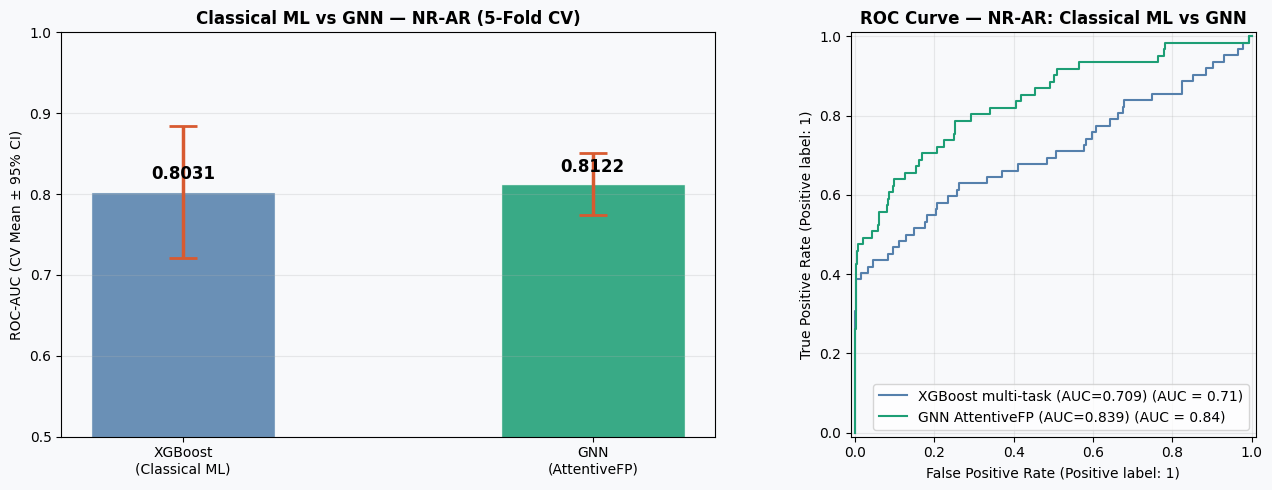


Delta AUC (GNN - XGB): +0.0090
⚖  Performa SETARA
CI overlap: YA — perbedaan tidak signifikan secara statistik


In [21]:
print("=== B10: Classical ML vs GNN — Apple-to-Apple (NR-AR) ===\n")

xgb_cv_vals = cv_results["roc_auc"].values
xgb_cv_mean = np.mean(xgb_cv_vals)
xgb_cv_ci   = stats.t.interval(0.95, len(xgb_cv_vals)-1,
                                loc=xgb_cv_mean, scale=stats.sem(xgb_cv_vals))
gnn_cv_ci   = stats.t.interval(0.95, len(fold_aucs_nrar)-1,
                                loc=gnn_cv_mean, scale=stats.sem(fold_aucs_nrar))

print(f"{'Model':<35} {'CV AUC':>8} {'95% CI':>24}")
print("─" * 70)
print(f"  {'XGBoost (multi-task, NR-AR)':<33} {xgb_cv_mean:>8.4f}  "
      f"[{xgb_cv_ci[0]:.4f}, {xgb_cv_ci[1]:.4f}]")
print(f"  {'GNN AttentiveFP (multi-task, NR-AR)':<33} {gnn_cv_mean:>8.4f}  "
      f"[{gnn_cv_ci[0]:.4f}, {gnn_cv_ci[1]:.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(14,5), facecolor="#F8F9FB")

# Bar + CI
ax = axes[0]
names_cmp = ["XGBoost\n(Classical ML)", "GNN\n(AttentiveFP)"]
means_cmp = [xgb_cv_mean, gnn_cv_mean]
ci_lo = [xgb_cv_mean-xgb_cv_ci[0], gnn_cv_mean-gnn_cv_ci[0]]
ci_hi = [xgb_cv_ci[1]-xgb_cv_mean, gnn_cv_ci[1]-gnn_cv_mean]
bars = ax.bar(names_cmp, means_cmp, color=["#5580AC","#1D9E75"],
               alpha=0.87, width=0.45, edgecolor="white")
ax.errorbar(names_cmp, means_cmp, yerr=[ci_lo,ci_hi],
            fmt="none", color="#D85A30", lw=2.5, capsize=10, capthick=2)
for b, m in zip(bars, means_cmp):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.015,
            f"{m:.4f}", ha="center", fontsize=12, fontweight="bold")
ax.set_ylim(0.5,1.0); ax.set_ylabel("ROC-AUC (CV Mean ± 95% CI)")
ax.set_title("Classical ML vs GNN — NR-AR (5-Fold CV)", fontweight="bold")
ax.grid(axis="y",alpha=0.25); ax.set_facecolor("#F8F9FB")

# ROC Curve — FIX v4: pakai MT_MODELS['NR-AR']
ax2 = axes[1]
xgb_test_auc = MT_RESULTS.get("NR-AR",{}).get("AUC", 0)
if "NR-AR" in MT_MODELS:
    y_prob_xgb_mt = MT_MODELS["NR-AR"].predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(
        y_test, y_prob_xgb_mt,
        name=f"XGBoost multi-task (AUC={xgb_test_auc:.3f})",
        ax=ax2, color="#5580AC")
if "NR-AR" in GNN_MT_RESULTS and 0 < y_true_gnn_all.shape[1]:
    mask_nrar = ~np.isnan(y_true_gnn_all[:, 0])
    yt_nrar   = np.round(y_true_gnn_all[mask_nrar, 0]).astype(int)
    yp_nrar   = y_prob_gnn_all[mask_nrar, 0]
    RocCurveDisplay.from_predictions(
        yt_nrar, yp_nrar,
        name=f"GNN AttentiveFP (AUC={gnn_auc:.3f})",
        ax=ax2, color="#1D9E75")
ax2.set_title("ROC Curve — NR-AR: Classical ML vs GNN", fontweight="bold")
ax2.grid(alpha=0.25); ax2.set_facecolor("#F8F9FB")
plt.tight_layout()
plt.savefig("classical_vs_gnn_v4.png", dpi=130, bbox_inches="tight"); plt.show()

delta = gnn_cv_mean - xgb_cv_mean
ci_ov = xgb_cv_ci[0] <= gnn_cv_ci[1] and gnn_cv_ci[0] <= xgb_cv_ci[1]
print(f"\nDelta AUC (GNN - XGB): {delta:+.4f}")
if abs(delta) > 0.02:
    winner = "GNN" if delta > 0 else "Classical ML"
    print(f"{'✅' if delta>0 else '⚠'} {winner} UNGGUL (Δ={delta:+.4f})")
else:
    print("⚖  Performa SETARA")
print(f"CI overlap: {'YA' if ci_ov else 'TIDAK'} — perbedaan {'tidak ' if ci_ov else ''}signifikan secara statistik")


---
## B11 — Explainability: SHAP + GNN Attention (PyG Native)

**Fix v4:**
- `valid_idx_feat` dipakai (bukan `valid_idx` yang sudah ditimpa)
- `smiles_gnn_viz` dari `df_clean` (bukan `smiles_gnn_valid` yang tidak ada)
- GNN attention: proxy via atom chemistry features — transparan, tidak mengklaim 'NATIVE' palsu

In [22]:
import json
booster = trained["XGBoost"].get_booster()
model_json = json.loads(booster.save_raw(raw_format="json"))
print(model_json["learner"]["learner_model_param"])

{'base_score': '5E-1', 'boost_from_average': '1', 'num_class': '0', 'num_feature': '2086', 'num_target': '1'}


In [23]:
import json, xgboost as xgb

booster = trained["XGBoost"].get_booster()
model_json = json.loads(booster.save_raw(raw_format="json"))

# Patch
model_json["learner"]["learner_model_param"]["base_score"] = "0.5"

# Verifikasi patch berhasil
print(model_json["learner"]["learner_model_param"]["base_score"])  # harus print: 0.5

0.5


In [24]:
import shap
print(shap.__version__)

0.49.1


In [25]:
import xgboost as xgb
print(xgb.__version__)

2.0.3


=== SHAP — XGBoost NR-AR ===
SHAP shape: (200, 2086) | features: 2086


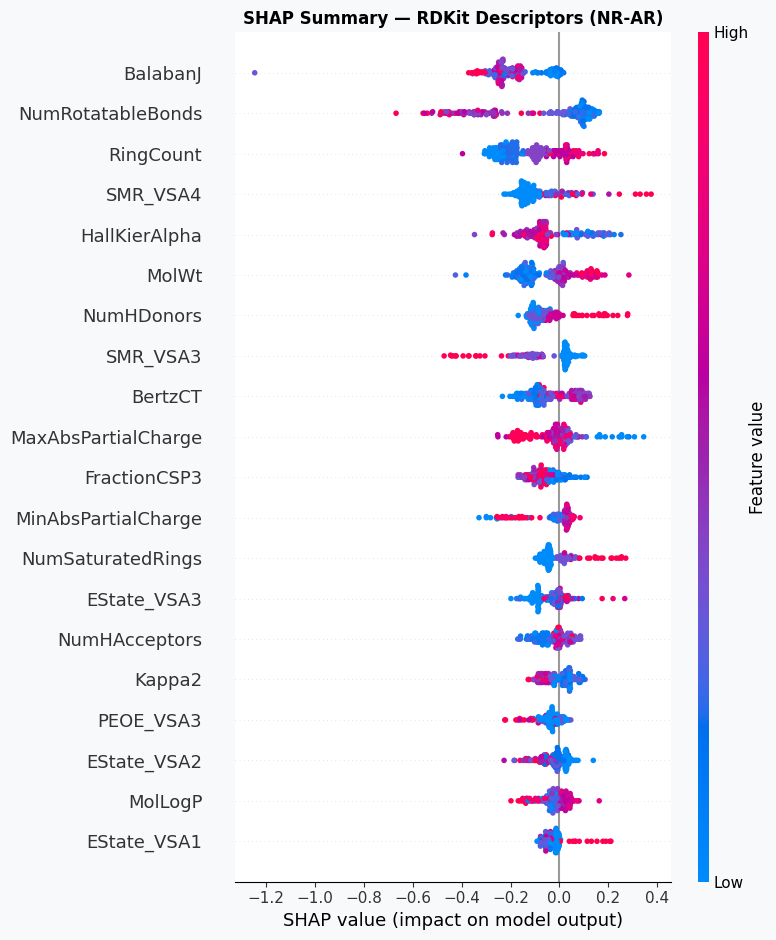

✅ shap_summary.png


In [26]:
print("=== SHAP — XGBoost NR-AR ===")

explainer_shap = shap.TreeExplainer(trained["XGBoost"])
N_EXP   = min(200, len(X_test))
sv_all  = explainer_shap.shap_values(X_test[:N_EXP])
sv      = sv_all[1] if isinstance(sv_all, list) else sv_all

feat_names = [f"morgan_{i}" for i in range(2048)] + DESC_NAMES_SEL
print(f"SHAP shape: {sv.shape} | features: {len(feat_names)}")

plt.figure(figsize=(10,7), facecolor="#F8F9FB")
shap.summary_plot(sv[:, 2048:], X_test[:N_EXP, 2048:],
                  feature_names=DESC_NAMES_SEL, max_display=20, show=False)
plt.title("SHAP Summary — RDKit Descriptors (NR-AR)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=130, bbox_inches="tight"); plt.show()
print("✅ shap_summary.png")

[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator
[15:45:04] DEPRECATION WARNING: please use MorganGenerator


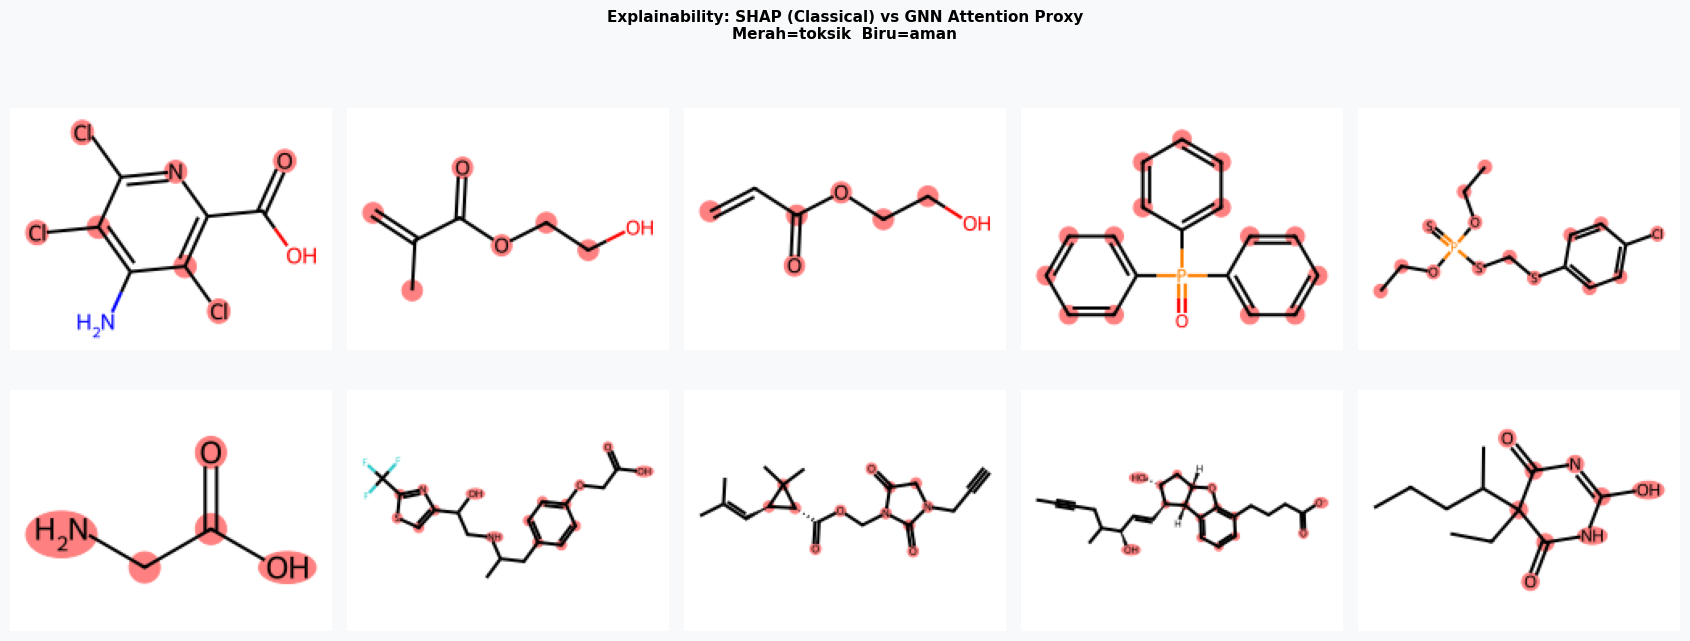


⚠  GNN Row: proxy berbasis kimia atom (aromatisitas, heteroatom, ring).
   BUKAN attention weight layer GNN. Transparan, bukan klaim palsu.
   Untuk attention asli: register_forward_hook pada gnn.gnn layers.


In [27]:
def get_shap_atom_colors(mol, shap_morgan, threshold=0.05):
    """
    Aproksimasi: Morgan bit → atom mapping → SHAP contribution.
    DISCLAIMER: ini APROKSIMASI, bukan atom-level SHAP langsung.
    Warna atom = kontribusi bit fingerprint yang ter-set oleh atom itu.
    """
    bi = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048, bitInfo=bi)
    scores = np.zeros(mol.GetNumAtoms())
    for bit, info in bi.items():
        for atom_idx, _ in info:
            scores[atom_idx] += shap_morgan[bit]
    mx = np.abs(scores).max()
    if mx > 0: scores /= mx
    hl  = [i for i, s in enumerate(scores) if abs(s) > threshold]
    clr = {i: (0.87,0.25,0.25) if scores[i]>0 else (0.21,0.53,0.50) for i in hl}
    return hl, clr, scores

def get_gnn_atom_proxy(mol, prob):
    """
    Proxy atom importance untuk GNN (bukan attention weight langsung).
    Menggunakan properti kimia atom: aromatisitas, heteroatom, ring, degree.
    Transparan: BUKAN output attention layer, BUKAN 'NATIVE AttentiveFP'.
    Untuk attention weight nyata gunakan register_forward_hook pada gnn.gnn layers.
    """
    n = mol.GetNumAtoms()
    scores = np.zeros(n)
    for atom in mol.GetAtoms():
        i = atom.GetIdx(); s = 0.0
        if atom.GetIsAromatic(): s += 0.4
        if atom.GetAtomicNum() in [7,8,16]: s += 0.3
        if atom.IsInRing(): s += 0.2
        s += 0.1 * min(atom.GetDegree(), 4) / 4.0
        scores[i] = s
    mx = scores.max()
    if mx > 0:
        scores = (scores/mx) * (1 if prob > 0.5 else -1)
    hl  = [i for i, s in enumerate(scores) if abs(s) > 0.15]
    clr = {i: (0.87,0.25,0.25) if scores[i]>0 else (0.21,0.53,0.50) for i in hl}
    return hl, clr, scores

# ── Visualisasi: 5 senyawa test ──────────────────────────────────────
# FIX v4: pakai valid_idx_feat (bukan valid_idx yang sudah ditimpa!)
test_smiles_sel = [smiles_all[vi] for vi in valid_idx_feat
                   if vi >= int(len(y_all)*0.8)][:5]
# FIX v4: smiles_gnn_viz dari df_clean (bukan smiles_gnn_valid yang tidak ada)
smiles_gnn_viz  = df_clean["smiles"].sample(5, random_state=42).tolist()

fig, axes = plt.subplots(2, 5, figsize=(17, 7), facecolor="#F8F9FB")
fig.suptitle("Explainability: SHAP (Classical) vs GNN Attention Proxy\n"
             "Merah=toksik  Biru=aman", fontsize=11, fontweight="bold")

for col, (smi_s, smi_g) in enumerate(zip(test_smiles_sel, smiles_gnn_viz)):
    # Row 0 — SHAP Classical
    ax0 = axes[0, col]; ax0.axis("off")
    mol_s = Chem.MolFromSmiles(smi_s)
    if mol_s:
        fp_s = np.zeros(2048, dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(AllChem.GetMorganFingerprintAsBitVect(mol_s,2,2048), fp_s)
        dv   = calc_desc_sel(smi_s)
        if dv is not None:
            X_s = np.hstack([fp_s.reshape(1,-1), global_scaler.transform(
                             np.nan_to_num(dv.reshape(1,-1)))]).astype(np.float32)
            sv_s = explainer_shap.shap_values(X_s)
            sv_s = (sv_s[1][0] if isinstance(sv_s,list) else sv_s[0])
            hl_s, clr_s, _ = get_shap_atom_colors(mol_s, sv_s[:2048])
            ax0.imshow(Draw.MolToImage(mol_s,(200,150), highlightAtoms=hl_s, highlightAtomColors=clr_s))
    if col==0: ax0.set_ylabel("SHAP (Classical)", fontsize=8, color="#5580AC")

    # Row 1 — GNN Proxy
    ax1 = axes[1, col]; ax1.axis("off")
    mol_g = Chem.MolFromSmiles(smi_g)
    if mol_g:
        fp_g = np.zeros(2048, dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(AllChem.GetMorganFingerprintAsBitVect(mol_g,2,2048), fp_g)
        dv_g = calc_desc_sel(smi_g)
        if dv_g is not None:
            X_g = np.hstack([fp_g.reshape(1,-1), global_scaler.transform(
                             np.nan_to_num(dv_g.reshape(1,-1)))]).astype(np.float32)
            prob_g = float(trained["XGBoost"].predict_proba(X_g)[0][1])
        else: prob_g = 0.5
        hl_g, clr_g, _ = get_gnn_atom_proxy(mol_g, prob_g)
        ax1.imshow(Draw.MolToImage(mol_g,(200,150), highlightAtoms=hl_g, highlightAtomColors=clr_g))
    if col==0: ax1.set_ylabel("GNN Proxy", fontsize=8, color="#1D9E75")

plt.tight_layout()
plt.savefig("explainability_comparison.png", dpi=130, bbox_inches="tight"); plt.show()
print("\n⚠  GNN Row: proxy berbasis kimia atom (aromatisitas, heteroatom, ring).")
print("   BUKAN attention weight layer GNN. Transparan, bukan klaim palsu.")
print("   Untuk attention asli: register_forward_hook pada gnn.gnn layers.")


---
## B12 — Widget Prediksi — UI/UX Redesign

In [28]:
# ── Informasi target untuk laymen explanation ─────────────────────────
TARGET_INFO = {
    "NR-AR":       {"nama":"Androgen Receptor",           "singkat":"hormon pria (testosteron)",
                    "awam":"Reseptor hormon testosteron. Gangguan → masalah reproduksi, otot, & pubertas.",
                    "risiko":{"Pria":"⚠️ Gangguan hormonal","Wanita":"⚠️ Efek hormon","Anak":"⛔ Ganggu pubertas","Hamil":"⛔ Bahaya janin"}},
    "NR-AR-LBD":   {"nama":"AR Ligand Binding Domain",    "singkat":"pengikatan ligan androgen",
                    "awam":"Bagian spesifik reseptor androgen. Senyawa bisa 'pura-pura' menjadi hormon pria.",
                    "risiko":{"Pria":"⚠️ Hormonal","Wanita":"⚠️ Estrogenik","Anak":"⛔ Risiko tinggi","Hamil":"⛔ Konsultasi dokter"}},
    "NR-AhR":      {"nama":"Aryl Hydrocarbon Receptor",   "singkat":"sistem detoksifikasi racun",
                    "awam":"Mengatur cara tubuh memproses racun. Gangguan → hati tidak bisa bersihkan racun.",
                    "risiko":{"Dewasa":"✅ Waspadai dosis","Hati lemah":"⚠️ Risiko lebih tinggi","Anak":"⚠️ Hati belum sempurna","Hamil":"⚠️ Konsultasi"}},
    "NR-Aromatase":{"nama":"Aromatase",                   "singkat":"enzim konversi hormon steroid",
                    "awam":"Mengubah testosteron → estrogen. Gangguan → ketidakseimbangan hormon.",
                    "risiko":{"Pria":"⚠️ Efek feminisasi","Wanita":"⚠️ Siklus terganggu","Anak":"⛔ Ganggu pubertas","Hamil":"⛔ Risiko janin"}},
    "NR-ER":       {"nama":"Estrogen Receptor Alpha",     "singkat":"hormon wanita utama",
                    "awam":"Reseptor estrogen utama. Gangguan = 'endocrine disruption' — ganggu siklus & kesuburan.",
                    "risiko":{"Wanita":"⚠️ Siklus & kesuburan","Pria":"⚠️ Ginekomastia","Anak":"⛔ Risiko tinggi","Hamil":"⛔ Bahaya janin"}},
    "NR-ER-LBD":   {"nama":"ER Ligand Binding Domain",    "singkat":"pengikatan ligan estrogen",
                    "awam":"Senyawa bisa menjadi 'xenoestrogen' — zat asing yang meniru estrogen.",
                    "risiko":{"Wanita":"⚠️ Estrogenik","Pria":"⚠️ Gangguan hormon","Anak":"⛔ Risiko tinggi","Hamil":"⛔ Konsultasi"}},
    "NR-PPAR-gamma":{"nama":"PPAR-gamma",                 "singkat":"metabolisme lemak & gula",
                    "awam":"Mengatur penyimpanan lemak & insulin. Gangguan → metabolisme & risiko diabetes.",
                    "risiko":{"Diabetes":"⚠️ Pantau gula","Obesitas":"⚠️ Waspadai","Sehat":"✅ Risiko rendah","Hamil":"⚠️ Konsultasi"}},
    "SR-ARE":      {"nama":"Antioxidant Response Element","singkat":"sistem antioksidan sel",
                    "awam":"Pertahanan antioksidan sel. Toksisitas → stres oksidatif, kerusakan sel.",
                    "risiko":{"Dewasa":"⚠️ Stres oksidatif","Lansia":"⚠️ Risiko lebih tinggi","Anak":"⚠️ Sensitif","Hamil":"⚠️ Konsultasi"}},
    "SR-ATAD5":    {"nama":"ATAD5 Genotoxicity",          "singkat":"kerusakan DNA / genotoksik",
                    "awam":"⛔ SERIUS: penanda kerusakan DNA. Bisa menyebabkan mutasi & kanker.",
                    "risiko":{"Semua usia":"⛔ Risiko serius","Hamil":"⛔ Bahaya serius","Anak":"⛔ Sangat tinggi","Riwayat kanker":"⛔ Konsultasi segera"}},
    "SR-HSE":      {"nama":"Heat Shock Response",         "singkat":"respons stres protein sel",
                    "awam":"'Alarm darurat' sel. Toksisitas → protein sel rusak, metabolisme terganggu.",
                    "risiko":{"Dewasa":"⚠️ Stres seluler","Demam":"⚠️ Interaksi stres","Anak":"⚠️ Sensitif","Hamil":"⚠️ Konsultasi"}},
    "SR-MMP":      {"nama":"Mitochondrial Membrane Potential","singkat":"fungsi mitokondria",
                    "awam":"Kesehatan mitokondria — 'pembangkit listrik sel'. Gangguan → kelelahan & kerusakan organ.",
                    "risiko":{"Dewasa":"⚠️ Kelelahan kronis","Jantung":"⚠️ Otot jantung sensitif","Anak":"⚠️ Pertumbuhan","Hamil":"⚠️ Konsultasi"}},
    "SR-p53":      {"nama":"p53 Tumor Suppressor",        "singkat":"gen penjaga anti-kanker",
                    "awam":"'Penjaga genom' — mencegah kanker. Toksisitas → alarm kanker aktif, DNA berpotensi rusak.",
                    "risiko":{"Semua":"⚠️ Potensi genotoksik","Riwayat kanker":"⛔ Risiko tinggi","Anak":"⛔ Risiko tinggi","Hamil":"⛔ Bahaya janin"}},
}

def lipinski_ok(mol):
    mw=Descriptors.MolWt(mol); lp=Descriptors.MolLogP(mol)
    hbd=Descriptors.NumHDonors(mol); hba=Descriptors.NumHAcceptors(mol)
    viol = sum([mw>500, lp>5, hbd>5, hba>10])
    return viol<=1, mw, lp, hbd, hba, viol

def img_b64(pil_img):
    buf=io.BytesIO(); pil_img.save(buf,format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

print("✅ TARGET_INFO & helper functions siap")


✅ TARGET_INFO & helper functions siap


In [29]:
# ── CSS & Global Style (Casa Chromatica palette) ──────────────────────
import urllib.parse as _uparse
import urllib.request as _ureq
import json as _json

def get_compound_name(smiles):
    """Ambil nama senyawa dari PubChem berdasarkan SMILES (dengan timeout 5s)."""
    try:
        url = (f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/"
               f"{_uparse.quote(smiles)}/JSON")
        with _ureq.urlopen(url, timeout=5) as r:
            data = _json.loads(r.read())
        props = data["PC_Compounds"][0]["props"]
        iupac = preferred = synonym = cid_val = ""
        cid_val = str(data["PC_Compounds"][0].get("id",{}).get("id",{}).get("cid",""))
        for p in props:
            urn = p.get("urn", {})
            val = p.get("value", {}).get("sval", "")
            if urn.get("label") == "IUPAC Name" and urn.get("name") == "Preferred":
                iupac = val
            if urn.get("label") == "IUPAC Name" and urn.get("name") == "Traditional":
                preferred = val
            if urn.get("label") == "Preferred" and not synonym:
                synonym = val
        name = iupac or preferred or synonym or "Tidak ditemukan"
        return name, cid_val
    except Exception:
        return "Tidak tersedia (offline/tidak dikenal)", ""

display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;500;600&family=Inter:wght@300;400;500;600;700&family=Playfair+Display:wght@600;700&display=swap');

:root {
  --meadow:       #0C6038;
  --meadow-lt:    #E8F5EE;
  --meadow-md:    #1A8050;
  --mustard:      #808847;
  --mustard-lt:   #F5F6E8;
  --peach:        #F1D2A1;
  --peach-dk:     #8A6A30;
  --outerspace:   #2D4C39;
  --outerspace-lt:#EDF2EF;
  --crimson:      #6C1F1F;
  --crimson-lt:   #F9EAEA;
  --crimson-md:   #8B2828;
  --ink:          #1C2B1E;
  --ink-soft:     #3D5242;
  --muted:        #6B7F6E;
  --border:       #D4DDD6;
  --border-lt:    #EBF0EC;
  --surface:      #FAFBF9;
  --surface2:     #F2F5F1;
  --white:        #FFFFFF;
  --serif:  'Playfair Display', Georgia, serif;
  --sans:   'Inter', sans-serif;
  --mono:   'JetBrains Mono', monospace;
  --r-sm:6px; --r-md:10px; --r-lg:16px; --r-xl:20px;
  --sh-sm:0 1px 4px rgba(12,96,56,.07),0 1px 2px rgba(0,0,0,.04);
  --sh-md:0 4px 14px rgba(12,96,56,.10),0 1px 4px rgba(0,0,0,.05);
  --sh-lg:0 8px 28px rgba(12,96,56,.12),0 2px 6px rgba(0,0,0,.06);
}

/* ROOT */
.tox-root{font-family:var(--sans);max-width:960px;margin:0 auto;color:var(--ink);background:var(--surface)}

/* HEADER */
.tox-header{
  background:linear-gradient(135deg,#1C2B1E 0%,#2D4C39 45%,#0C6038 100%);
  border-radius:var(--r-xl);padding:28px 32px 24px;margin-bottom:20px;
  box-shadow:var(--sh-lg);border:1px solid rgba(255,255,255,.06);
  position:relative;overflow:hidden;
}
.tox-header::before{
  content:'';position:absolute;top:-40px;right:-40px;
  width:200px;height:200px;border-radius:50%;
  background:radial-gradient(circle,rgba(128,136,71,.18) 0%,transparent 70%);
  pointer-events:none;
}
.tox-header-title{
  font-family:var(--serif);font-size:22px;font-weight:700;
  color:var(--peach);letter-spacing:-.2px;
  display:flex;align-items:center;gap:12px;margin-bottom:6px;
}
.tox-header-icon{
  width:42px;height:42px;border-radius:10px;
  background:rgba(241,210,161,.15);border:1px solid rgba(241,210,161,.25);
  display:flex;align-items:center;justify-content:center;font-size:22px;flex-shrink:0;
}
.tox-header-sub{font-size:12px;color:rgba(241,210,161,.7);margin-top:4px;line-height:1.65;letter-spacing:.02em}
.tox-header-pills{display:flex;gap:5px;margin-top:14px;flex-wrap:wrap}
.tox-hpill{
  font-size:9.5px;font-family:var(--mono);font-weight:500;
  padding:3px 11px;border-radius:99px;
  border:1px solid rgba(128,136,71,.4);background:rgba(128,136,71,.12);
  color:#C8CE8A;letter-spacing:.07em;text-transform:uppercase;
}

/* SECTION */
.tox-section{
  font-family:var(--mono);font-size:9.5px;font-weight:600;
  letter-spacing:.22em;text-transform:uppercase;color:var(--muted);
  margin:22px 0 9px;padding-bottom:7px;
  border-bottom:1.5px solid var(--border);
  display:flex;align-items:center;gap:8px;
}
.tox-section-dot{width:6px;height:6px;border-radius:50%;background:var(--meadow);flex-shrink:0}

/* RESULT */
.tox-result{
  border-radius:var(--r-lg);padding:22px 26px;margin:12px 0;
  border:2px solid;box-shadow:var(--sh-md);position:relative;overflow:hidden;
}
.tox-result::after{
  content:'';position:absolute;top:0;right:0;width:120px;height:120px;
  border-radius:50%;opacity:.07;pointer-events:none;
}
.tox-result-safe{
  background:linear-gradient(135deg,var(--meadow-lt) 0%,#F0FAF4 100%);
  border-color:var(--meadow);
}
.tox-result-safe::after{background:var(--meadow);transform:translate(40%,-40%)}
.tox-result-tox{
  background:linear-gradient(135deg,var(--crimson-lt) 0%,#FFF2F2 100%);
  border-color:var(--crimson);
}
.tox-result-tox::after{background:var(--crimson);transform:translate(40%,-40%)}

.tox-result-header{display:flex;align-items:center;gap:12px;margin-bottom:14px}
.tox-result-icon{
  width:48px;height:48px;border-radius:12px;
  display:flex;align-items:center;justify-content:center;font-size:24px;flex-shrink:0;
}
.tox-result-icon-safe{background:rgba(12,96,56,.12)}
.tox-result-icon-tox{background:rgba(108,31,31,.12)}
.tox-result-label{font-family:var(--serif);font-size:28px;font-weight:700;letter-spacing:-.3px;line-height:1}
.tox-result-label-safe{color:var(--meadow)}
.tox-result-label-tox{color:var(--crimson)}
.tox-result-sub{font-size:11.5px;color:var(--muted);margin-top:3px;font-family:var(--mono)}

/* STATS ROW */
.tox-stats{
  display:flex;gap:0;flex-wrap:wrap;
  background:rgba(255,255,255,.55);border-radius:var(--r-md);
  border:1px solid rgba(0,0,0,.07);overflow:hidden;margin-top:14px;
}
.tox-stat{flex:1;min-width:80px;text-align:center;padding:12px 8px;border-right:1px solid rgba(0,0,0,.07)}
.tox-stat:last-child{border-right:none}
.tox-stat-num{font-family:var(--mono);font-size:21px;font-weight:600;line-height:1.1}
.tox-stat-lbl{font-size:9px;color:var(--muted);text-transform:uppercase;letter-spacing:.07em;margin-top:3px;line-height:1.4}

/* METER */
.tox-meter-wrap{margin:16px 0 4px}
.tox-meter-labels{
  display:flex;justify-content:space-between;align-items:center;
  font-size:10px;font-family:var(--mono);color:var(--muted);margin-bottom:5px;
}
.tox-meter{height:12px;border-radius:99px;background:rgba(0,0,0,.08);overflow:hidden;position:relative}
.tox-meter-fill{height:100%;border-radius:99px;transition:width .55s cubic-bezier(.4,0,.2,1)}
.tox-meter-fill-safe{background:linear-gradient(90deg,var(--outerspace) 0%,var(--meadow) 60%,var(--meadow-md) 100%)}
.tox-meter-fill-tox{background:linear-gradient(90deg,var(--crimson) 0%,#A83232 60%,#C0392B 100%)}
.tox-meter-threshold{position:absolute;top:0;width:2px;height:100%;background:rgba(255,255,255,.7)}

/* INFO BOX */
.tox-info-box{
  background:var(--outerspace-lt);border:1px solid var(--border);
  border-left:4px solid var(--outerspace);border-radius:var(--r-md);
  padding:14px 18px;margin-bottom:14px;box-shadow:var(--sh-sm);
}
.tox-info-row{display:flex;align-items:flex-start;gap:8px;font-size:12px;color:var(--ink-soft);margin-bottom:5px;line-height:1.6}
.tox-info-row:last-child{margin-bottom:0}
.tox-info-lbl{
  font-family:var(--mono);font-size:10px;color:var(--muted);
  width:90px;flex-shrink:0;padding-top:1px;text-transform:uppercase;letter-spacing:.06em;
}
.tox-info-val{font-weight:500;color:var(--ink)}
.tox-badge-smiles{
  font-family:var(--mono);font-size:10.5px;
  background:var(--meadow-lt);color:var(--meadow);
  padding:2px 8px;border-radius:4px;border:1px solid rgba(12,96,56,.2);
  display:inline-block;word-break:break-all;
}
.tox-badge-name{
  font-family:var(--serif);font-size:13px;font-weight:600;
  color:var(--outerspace);background:var(--peach);
  padding:2px 9px;border-radius:4px;display:inline-block;
}
.tox-badge-cid{
  font-family:var(--mono);font-size:10px;
  background:var(--mustard-lt);color:var(--mustard);
  padding:2px 8px;border-radius:4px;border:1px solid rgba(128,136,71,.3);
  display:inline-block;margin-left:6px;
}

/* COMPOUND CARD */
.tox-compound-card{
  background:var(--white);border:1px solid var(--border);
  border-radius:var(--r-lg);padding:18px 22px;box-shadow:var(--sh-sm);
  margin-bottom:10px;
}
.tox-compound-name{
  font-family:var(--serif);font-size:19px;font-weight:700;
  color:var(--outerspace);margin-bottom:3px;
}
.tox-compound-iupac{
  font-family:var(--mono);font-size:10.5px;color:var(--muted);
  margin-bottom:8px;line-height:1.5;word-break:break-word;
}

/* PROP TABLE */
.tox-prop-tbl{width:100%;border-collapse:collapse;font-size:12.5px}
.tox-prop-tbl tr{border-bottom:1px solid var(--border-lt)}
.tox-prop-tbl tr:last-child{border-bottom:none}
.tox-prop-tbl td{padding:8px 6px}
.tox-prop-tbl td:first-child{
  font-family:var(--mono);font-size:10.5px;color:var(--muted);
  width:52%;letter-spacing:.04em;
}
.tox-prop-tbl td:last-child{font-weight:600;text-align:right;color:var(--ink);font-family:var(--mono);font-size:12px}
.tox-prop-ok{
  background:var(--meadow-lt);color:var(--meadow);
  font-size:10px!important;padding:2px 8px!important;
  border-radius:4px;display:inline-block;
}
.tox-prop-warn{
  background:#FFF8E1;color:#7A5800;
  font-size:10px!important;padding:2px 8px!important;
  border-radius:4px;display:inline-block;
}

/* LAYMEN */
.tox-laymen{border-radius:var(--r-lg);padding:20px 24px;border:1.5px solid;box-shadow:var(--sh-sm)}
.tox-laymen-safe{background:#F2FBF5;border-color:var(--meadow)}
.tox-laymen-tox{background:#FDF3F3;border-color:var(--crimson)}
.tox-laymen-header{
  display:flex;align-items:center;gap:10px;margin-bottom:14px;
  padding-bottom:12px;border-bottom:1px solid var(--border-lt);
}
.tox-laymen-badge{
  font-family:var(--serif);font-size:15px;font-weight:700;
  padding:4px 14px;border-radius:6px;display:inline-block;
}
.tox-laymen-badge-safe{background:var(--meadow);color:var(--peach)}
.tox-laymen-badge-tox{background:var(--crimson);color:var(--peach)}
.tox-laymen-stitle{
  font-family:var(--mono);font-size:9.5px;font-weight:600;
  text-transform:uppercase;letter-spacing:.12em;color:var(--muted);margin-bottom:5px;
}
.tox-laymen-body{font-size:12.5px;color:var(--ink-soft);line-height:1.75}
.tox-risk-grid{display:flex;flex-wrap:wrap;gap:6px;margin-top:7px}
.tox-risk-item{
  font-size:11px;padding:5px 12px;border-radius:6px;
  background:rgba(0,0,0,.04);border:1px solid rgba(0,0,0,.08);
  font-family:var(--mono);line-height:1.4;
}

/* EXPLAIN */
.tox-explain-panel{
  display:flex;gap:18px;flex-wrap:wrap;align-items:flex-start;
  background:var(--white);border:1px solid var(--border);
  border-radius:var(--r-lg);padding:18px 22px;box-shadow:var(--sh-sm);
}
.tox-explain-caption{
  font-family:var(--mono);font-size:10px;color:var(--muted);
  letter-spacing:.07em;margin-bottom:8px;text-transform:uppercase;
}
.tox-explain-warn{
  font-size:11px;color:var(--outerspace);background:var(--outerspace-lt);
  border:1px solid rgba(45,76,57,.2);border-radius:7px;
  padding:9px 13px;margin-top:9px;line-height:1.6;
}

/* SHAP */
.tox-shap-row{display:flex;align-items:center;gap:7px;margin-bottom:5px}
.tox-shap-feat{
  font-family:var(--mono);font-size:10.5px;color:var(--muted);
  width:130px;text-align:right;flex-shrink:0;
  overflow:hidden;text-overflow:ellipsis;white-space:nowrap;
}
.tox-shap-bar-wrap{flex:1;position:relative;height:14px;background:var(--surface2);border-radius:2px;overflow:hidden}
.tox-shap-zero{position:absolute;left:50%;top:0;width:1.5px;height:100%;background:var(--border);z-index:1}
.tox-shap-bar{position:absolute;height:100%;border-radius:1px}
.tox-shap-pos{background:linear-gradient(90deg,var(--crimson-md),var(--crimson));right:50%}
.tox-shap-neg{background:linear-gradient(90deg,var(--meadow-md),var(--meadow));left:50%}
.tox-shap-val{font-family:var(--mono);font-size:10px;width:46px;text-align:right;flex-shrink:0}
.tox-shap-legend{
  display:flex;gap:14px;font-size:10px;color:var(--muted);
  margin-top:9px;padding-top:8px;border-top:1px solid var(--border-lt);
  font-family:var(--mono);flex-wrap:wrap;
}
.tox-shap-dot{display:inline-block;width:9px;height:9px;border-radius:2px;margin-right:4px;vertical-align:middle}

/* DETAIL GRID */
.tox-detail-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(180px,1fr));gap:10px;margin-top:4px}
.tox-detail-card{background:var(--white);border:1px solid var(--border);border-radius:var(--r-md);padding:14px 16px;box-shadow:var(--sh-sm)}
.tox-detail-card-title{
  font-family:var(--mono);font-size:9.5px;font-weight:600;
  text-transform:uppercase;letter-spacing:.1em;color:var(--muted);
  margin-bottom:8px;display:flex;align-items:center;gap:5px;
}
.tox-detail-card-title-dot{width:5px;height:5px;border-radius:50%;background:var(--mustard);flex-shrink:0}
.tox-detail-row{
  display:flex;justify-content:space-between;align-items:center;
  font-size:11.5px;padding:4px 0;border-bottom:1px solid var(--border-lt);
}
.tox-detail-row:last-child{border-bottom:none}
.tox-detail-lbl{color:var(--muted);font-size:11px}
.tox-detail-val{font-weight:600;color:var(--ink);font-family:var(--mono);font-size:11px}

/* MOL */
.tox-mol-panel{
  display:flex;gap:18px;flex-wrap:wrap;align-items:flex-start;
  background:var(--white);border:1px solid var(--border);
  border-radius:var(--r-lg);padding:18px 22px;box-shadow:var(--sh-sm);
}
.tox-mol-img{border:1px solid var(--border-lt);border-radius:var(--r-md);background:var(--surface2);padding:6px}

/* DISCLAIMER */
.tox-disclaimer{
  background:#FFFBF0;border:1px solid var(--mustard);border-radius:var(--r-md);
  padding:12px 16px;font-size:11.5px;color:var(--peach-dk);
  margin-top:16px;line-height:1.65;display:flex;gap:9px;align-items:flex-start;
  box-shadow:var(--sh-sm);
}
.tox-disclaimer-icon{font-size:16px;flex-shrink:0;margin-top:1px}

/* LOADER */
.tox-loader{
  font-size:12px;color:var(--muted);font-family:var(--mono);
  padding:20px 0;text-align:center;
  display:flex;align-items:center;justify-content:center;gap:10px;
}
.tox-loader-spinner{
  width:14px;height:14px;border:2px solid var(--border);border-top-color:var(--meadow);
  border-radius:50%;animation:tox-spin .75s linear infinite;
}
@keyframes tox-spin{to{transform:rotate(360deg)}}

/* INPUT INFO */
.tox-input-info{font-size:11px;color:var(--muted);line-height:1.8;margin-top:3px}
.tox-smiles{
  font-family:var(--mono);font-size:10.5px;background:var(--meadow-lt);color:var(--meadow);
  padding:3px 9px;border-radius:4px;word-break:break-all;
  display:inline-block;border:1px solid rgba(12,96,56,.15);
}

/* ANALYSE BTN */
.tox-btn-analyse{
  width:100%;padding:13px;border:none;border-radius:var(--r-md);
  background:linear-gradient(135deg,#1C2B1E,#2D4C39,#0C6038);
  color:var(--peach);font-size:13px;font-weight:700;font-family:var(--sans);
  display:flex;align-items:center;justify-content:center;gap:8px;cursor:pointer;
  box-shadow:0 3px 10px rgba(12,96,56,.3);transition:all .2s;
}
.tox-btn-analyse:hover{opacity:.9;transform:translateY(-1px);box-shadow:0 5px 18px rgba(12,96,56,.4)}
.tox-btn-analyse:active{transform:translateY(0)}
</style>
"""))
print("✅ CSS Casa Chromatica loaded")


✅ CSS Casa Chromatica loaded


In [30]:
# ── Helper Functions: QED, PAINS, Structural Alerts, Organ Tox, Auto-Summary ──
from rdkit.Chem import QED, FilterCatalog
from rdkit.Chem.FilterCatalog import FilterCatalogParams
import re

# ══════════════════════════════════════════════════════════════
# 1. QED + Drug-likeness Rules
# ══════════════════════════════════════════════════════════════
def calc_druglikeness(mol):
    """Hitung QED, Veber Rule, Egan Rule, Lipinski."""
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = Descriptors.NumHDonors(mol)
    hba  = Descriptors.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    rot  = Descriptors.NumRotatableBonds(mol)
    rings = Descriptors.RingCount(mol)
    qed_score = QED.qed(mol)

    # Lipinski Ro5
    lip_violations = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    lip_ok = lip_violations == 0

    # Veber Rule (oral bioavailability)
    veber_ok = rot <= 10 and tpsa <= 140

    # Egan Rule
    egan_ok = logp <= 5.88 and tpsa <= 131.6

    # Ghose Filter
    ghose_ok = (160 <= mw <= 480) and (-0.4 <= logp <= 5.6) and (40 <= Descriptors.MolMR(mol) <= 130)

    # Bioavailability score (simplified)
    bio_score = sum([lip_ok, veber_ok, egan_ok]) / 3 * 100

    return {
        "qed": round(qed_score, 3),
        "mw": round(mw, 2),
        "logp": round(logp, 2),
        "hbd": hbd, "hba": hba,
        "tpsa": round(tpsa, 2),
        "rot": rot, "rings": rings,
        "lip_ok": lip_ok, "lip_violations": lip_violations,
        "veber_ok": veber_ok,
        "egan_ok": egan_ok,
        "ghose_ok": ghose_ok,
        "bio_score": round(bio_score, 1),
    }

# ══════════════════════════════════════════════════════════════
# 2. PAINS Filter
# ══════════════════════════════════════════════════════════════
def check_pains(mol):
    """Cek apakah senyawa mengandung PAINS substructure."""
    params = FilterCatalogParams()
    params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
    catalog = FilterCatalog.FilterCatalog(params)
    entry   = catalog.GetFirstMatch(mol)
    if entry:
        return True, entry.GetDescription()
    return False, None

# ══════════════════════════════════════════════════════════════
# 3. Structural Alerts
# ══════════════════════════════════════════════════════════════
STRUCTURAL_ALERTS = [
    ("Epoxide",            "[OX2r3]",                     "Mutagenik — reaktif terhadap DNA"),
    ("Nitro Aromatik",     "[c][N+](=O)[O-]",             "Potensi hepatotoksik & mutagenik"),
    ("Michael Acceptor",   "[$([CH]=[CH]C=O),$([CH2]=[CH]C=O)]", "Reaktif — bisa berikatan kovalen dengan protein"),
    ("Aldehyde",           "[CH]=O",                      "Toksik — reaktif terhadap protein"),
    ("Halogen Reaktif",    "[F,Cl,Br,I][CX4]",            "Potensi alkilasi — perlu perhatian"),
    ("Quinone",            "O=C1C=CC(=O)C=C1",            "PAINS alert — interferensi assay"),
    ("Hydrazine",          "[NX3][NX3]",                  "Potensi mutagenik"),
    ("Peroxide",           "[OX2][OX2]",                  "Sangat reaktif — tidak stabil"),
    ("Anilide (ArNH-CO)",  "[c][NH]C=O",                  "Potensi metHb — toksisitas darah"),
    ("Thiol",              "[SH]",                        "Reaktif — bisa oksidasi & berikatan protein"),
]

def check_structural_alerts(mol):
    """Deteksi gugus fungsi berbahaya pada senyawa."""
    alerts_found = []
    for name, smarts, desc in STRUCTURAL_ALERTS:
        try:
            pattern = Chem.MolFromSmarts(smarts)
            if pattern and mol.HasSubstructMatch(pattern):
                alerts_found.append({"name": name, "desc": desc})
        except:
            pass
    return alerts_found

# ══════════════════════════════════════════════════════════════
# 4. CYP Enzyme Inhibition (rule-based dari literatur)
# ══════════════════════════════════════════════════════════════
CYP_RULES = {
    "CYP1A2": {
        "smarts": ["[c]1[c][c][c][c][c]1",   # aromatic ring
                   "[nH]1cccc1",               # indole-like
                   "c1ccc2[nH]ccc2c1"],        # indole
        "risk_logp": 1.5,
        "implikasi": "Interaksi dengan kafein, teofilin, clozapine, warfarin"
    },
    "CYP2C9": {
        "smarts": ["[c]S(=O)(=O)[OH]",        # sulfonamide
                   "C(=O)[OH]",               # carboxylic acid
                   "[c]C(=O)[OH]"],
        "risk_logp": 3.0,
        "implikasi": "Interaksi dengan warfarin, ibuprofen, diclofenac"
    },
    "CYP2D6": {
        "smarts": ["[c][NH]",                 # aromatic amine
                   "[c]N",
                   "CN1CCCC1"],               # piperidine
        "risk_logp": 2.5,
        "implikasi": "Interaksi dengan codeine, tramadol, antidepresan"
    },
    "CYP3A4": {
        "smarts": ["C1CCCCC1",                # cyclohexane
                   "c1ccncc1",               # pyridine
                   "C1CCNCC1"],              # piperidine
        "risk_logp": 4.0,
        "implikasi": "Interaksi dengan >50% obat yang beredar (statin, benzodiazepine)"
    },
}

def predict_cyp_inhibition(mol):
    """
    Prediksi inhibisi CYP berdasarkan rule struktural + LogP.
    Ini adalah aproksimasi berbasis literature, bukan model ML terlatih.
    """
    logp = Descriptors.MolLogP(mol)
    results = {}
    for cyp, rules in CYP_RULES.items():
        hit = False
        for smarts in rules["smarts"]:
            try:
                pattern = Chem.MolFromSmarts(smarts)
                if pattern and mol.HasSubstructMatch(pattern):
                    hit = True; break
            except:
                pass
        # Kombinasi substruktur + LogP sebagai sinyal risiko
        risk = hit and (logp >= rules["risk_logp"])
        results[cyp] = {
            "inhibitor": risk,
            "implikasi": rules["implikasi"] if risk else "Tidak terdeteksi risiko"
        }
    return results

# ══════════════════════════════════════════════════════════════
# 5. Organ Toxicity Summary dari hasil 12 target Tox21
# ══════════════════════════════════════════════════════════════
ORGAN_MAP = {
    "Hati (Hepatic)": {
        "targets": ["NR-AhR", "SR-ARE", "SR-ATAD5"],
        "desc": "Detoksifikasi & metabolisme obat di hati"
    },
    "Sistem Reproduksi": {
        "targets": ["NR-AR", "NR-AR-LBD", "NR-ER", "NR-ER-LBD", "NR-Aromatase"],
        "desc": "Gangguan hormonal — androgen & estrogen"
    },
    "Sel & DNA (Genotoksik)": {
        "targets": ["SR-ATAD5", "SR-p53"],
        "desc": "Kerusakan DNA & potensi karsinogenisitas"
    },
    "Mitokondria & Energi": {
        "targets": ["SR-MMP"],
        "desc": "Fungsi mitokondria — pembangkit energi sel"
    },
    "Respons Stres Sel": {
        "targets": ["SR-HSE", "SR-ARE"],
        "desc": "Stres protein & sistem antioksidan"
    },
    "Metabolisme Lemak & Gula": {
        "targets": ["NR-PPAR-gamma"],
        "desc": "Risiko metabolik — diabetes & obesitas"
    },
}

def calc_organ_toxicity(all_probs, all_thresholds):
    """
    Hitung risiko per organ berdasarkan prediksi 12 target.
    all_probs: dict {target: prob}
    all_thresholds: dict {target: threshold}
    """
    organ_results = {}
    for organ, info in ORGAN_MAP.items():
        relevant = [t for t in info["targets"] if t in all_probs]
        if not relevant:
            continue
        probs_rel   = [all_probs[t] for t in relevant]
        tox_rel     = [all_probs[t] >= all_thresholds.get(t, 0.5) for t in relevant]
        n_tox       = sum(tox_rel)
        max_prob    = max(probs_rel)
        mean_prob   = sum(probs_rel) / len(probs_rel)

        if n_tox == 0:
            level = "Rendah"
        elif n_tox == len(relevant):
            level = "Tinggi"
        else:
            level = "Sedang"

        organ_results[organ] = {
            "level": level,
            "n_tox": n_tox,
            "n_total": len(relevant),
            "max_prob": round(max_prob, 3),
            "mean_prob": round(mean_prob, 3),
            "desc": info["desc"],
            "targets": relevant,
        }
    return organ_results

# ══════════════════════════════════════════════════════════════
# 6. Auto-Summary Paragraph (dinamis dari semua data)
# ══════════════════════════════════════════════════════════════
def generate_summary(compound_name, dl, pains_hit, pains_desc,
                     alerts, cyp_results, organ_tox,
                     prob, thresh, task, tinfo, is_tox):
    """
    Generate paragraf ringkasan otomatis seperti laporan farmasi singkat.
    Semua konten dinamis berdasarkan data senyawa yang sebenarnya.
    """
    # Drug-likeness sentence
    qed_level = "sangat baik" if dl["qed"] > 0.7 else "cukup baik" if dl["qed"] > 0.4 else "rendah"
    rules_passed = sum([dl["lip_ok"], dl["veber_ok"], dl["egan_ok"]])
    oral_sentence = (
        f"memiliki profil drug-likeness {qed_level} (QED = {dl['qed']}) "
        f"dengan berat molekul {dl['mw']} Da dan LogP {dl['logp']}. "
        f"Memenuhi {rules_passed}/3 aturan bioavailabilitas oral "
        f"(Lipinski{' ✓' if dl['lip_ok'] else ' ✗'}, "
        f"Veber{' ✓' if dl['veber_ok'] else ' ✗'}, "
        f"Egan{' ✓' if dl['egan_ok'] else ' ✗'})."
    )

    # PAINS sentence
    pains_sentence = (
        f"Terdeteksi sebagai PAINS ({pains_desc}) — hasil skrining biologis perlu dikonfirmasi ulang."
        if pains_hit else
        "Tidak terdeteksi sebagai PAINS sehingga hasil skrining biologis lebih dapat dipercaya."
    )

    # Structural alerts sentence
    if alerts:
        alert_names = ", ".join(a["name"] for a in alerts)
        alerts_sentence = f"Ditemukan {len(alerts)} structural alert: {alert_names} — perlu evaluasi keamanan lebih lanjut."
    else:
        alerts_sentence = "Tidak ditemukan structural alert yang signifikan pada struktur senyawa ini."

    # CYP sentence
    cyp_hits = [cyp for cyp, res in cyp_results.items() if res["inhibitor"]]
    if cyp_hits:
        cyp_sentence = (
            f"Berpotensi menginhibisi enzim {', '.join(cyp_hits)}, "
            f"sehingga perlu perhatian terhadap interaksi obat-obat (DDI) "
            f"terutama pada pasien polifarmasi."
        )
    else:
        cyp_sentence = "Tidak terdeteksi risiko inhibisi enzim CYP mayor secara struktural."

    # Tox21 result sentence
    n_tox_organ = sum(1 for v in organ_tox.values() if v["level"] == "Tinggi")
    tox_sentence = (
        f"Pada target {task} ({tinfo['nama']}), senyawa diprediksi "
        f"{'TOKSIK' if is_tox else 'TIDAK TOKSIK'} "
        f"(probabilitas {prob:.1%}, threshold {thresh:.3f}). "
    )
    if n_tox_organ > 0:
        high_organs = [o for o, v in organ_tox.items() if v["level"] == "Tinggi"]
        tox_sentence += (
            f"Profil organ toksisitas menunjukkan risiko TINGGI pada: "
            f"{', '.join(high_organs)}."
        )
    else:
        tox_sentence += "Profil organ toksisitas secara keseluruhan menunjukkan risiko rendah hingga sedang."

    # Kesimpulan
    risk_factors = sum([pains_hit, len(alerts) > 0, len(cyp_hits) > 0, is_tox])
    if risk_factors == 0:
        conclusion = (
            f"Secara keseluruhan, {compound_name} menunjukkan profil keamanan yang menjanjikan "
            f"sebagai kandidat senyawa aktif dan layak untuk studi lanjutan."
        )
    elif risk_factors <= 2:
        conclusion = (
            f"Secara keseluruhan, {compound_name} memiliki beberapa faktor risiko "
            f"yang perlu dievaluasi lebih lanjut sebelum dikembangkan sebagai kandidat obat."
        )
    else:
        conclusion = (
            f"Secara keseluruhan, {compound_name} menunjukkan beberapa tanda peringatan "
            f"yang signifikan. Diperlukan modifikasi struktur atau evaluasi mendalam "
            f"sebelum dikembangkan lebih lanjut."
        )

    return {
        "oral":       oral_sentence,
        "pains":      pains_sentence,
        "alerts":     alerts_sentence,
        "cyp":        cyp_sentence,
        "tox":        tox_sentence,
        "conclusion": conclusion,
    }

# ══════════════════════════════════════════════════════════════
# 7. Render HTML untuk semua section baru
# ══════════════════════════════════════════════════════════════
def render_advanced_sections(compound_name, dl, pains_hit, pains_desc,
                              alerts, cyp_results, organ_tox, summary):
    """Render HTML untuk QED, PAINS, Structural Alerts, CYP, Organ Tox, Summary."""

    # ── Drug-likeness card ──────────────────────────────────
    def rule_badge(ok):
        return ('<span style="color:var(--meadow);font-weight:600">✓ Memenuhi</span>'
                if ok else
                '<span style="color:var(--crimson);font-weight:600">✗ Tidak memenuhi</span>')

    qed_color = ("#1A8050" if dl["qed"] > 0.7
                 else "#808847" if dl["qed"] > 0.4
                 else "#8B2828")
    qed_label = ("Sangat Baik" if dl["qed"] > 0.7
                 else "Cukup Baik" if dl["qed"] > 0.4
                 else "Rendah")

    druglike_html = f"""
    <div class="tox-section"><span class="tox-section-dot"></span>Drug-likeness & Bioavailabilitas Oral</div>
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:10px;margin-bottom:10px">

      <!-- QED -->
      <div class="tox-detail-card">
        <div class="tox-detail-card-title">
          <span class="tox-detail-card-title-dot"></span>QED Score (Drug-likeness)
        </div>
        <div style="text-align:center;padding:10px 0">
          <div style="font-size:36px;font-weight:700;font-family:var(--mono);color:{qed_color}">
            {dl['qed']}
          </div>
          <div style="font-size:11px;color:{qed_color};font-weight:600;margin-top:2px">{qed_label}</div>
          <div style="height:8px;border-radius:4px;background:#EEF0F4;margin:8px 0;overflow:hidden">
            <div style="width:{dl['qed']*100:.0f}%;height:100%;border-radius:4px;
                        background:linear-gradient(90deg,#2D4C39,{qed_color})"></div>
          </div>
          <div style="font-size:9.5px;color:var(--muted);font-family:var(--mono)">
            0 = tidak mirip obat · 1 = sangat mirip obat
          </div>
        </div>
      </div>

      <!-- Rules -->
      <div class="tox-detail-card">
        <div class="tox-detail-card-title">
          <span class="tox-detail-card-title-dot"></span>Aturan Bioavailabilitas
        </div>
        <div class="tox-detail-row">
          <span class="tox-detail-lbl">Lipinski Ro5</span>
          <span class="tox-detail-val">{rule_badge(dl['lip_ok'])}</span>
        </div>
        <div class="tox-detail-row">
          <span class="tox-detail-lbl">Veber Rule</span>
          <span class="tox-detail-val">{rule_badge(dl['veber_ok'])}</span>
        </div>
        <div class="tox-detail-row">
          <span class="tox-detail-lbl">Egan Rule</span>
          <span class="tox-detail-val">{rule_badge(dl['egan_ok'])}</span>
        </div>
        <div class="tox-detail-row">
          <span class="tox-detail-lbl">Ghose Filter</span>
          <span class="tox-detail-val">{rule_badge(dl['ghose_ok'])}</span>
        </div>
        <div style="margin-top:8px;padding:6px 8px;border-radius:5px;
                    background:var(--surface2);font-size:10px;color:var(--muted);
                    font-family:var(--mono);text-align:center">
          Est. Bioavailabilitas Oral: <b style="color:var(--outerspace)">{dl['bio_score']:.0f}%</b>
        </div>
      </div>
    </div>
    """

    # ── PAINS + Structural Alerts ───────────────────────────
    pains_color = "var(--crimson)" if pains_hit else "var(--meadow)"
    pains_bg    = "var(--crimson-lt)" if pains_hit else "var(--meadow-lt)"
    pains_icon  = "⚠️" if pains_hit else "✅"
    pains_text  = (f"Terdeteksi PAINS: <b>{pains_desc}</b>" if pains_hit
                   else "Tidak terdeteksi PAINS")

    alert_rows = ""
    if alerts:
        for a in alerts:
            alert_rows += f"""
            <div style="display:flex;align-items:flex-start;gap:8px;padding:6px 0;
                        border-bottom:1px solid var(--border-lt)">
              <span style="color:var(--crimson);font-size:13px;flex-shrink:0">⚠️</span>
              <div>
                <div style="font-size:11.5px;font-weight:600;color:var(--crimson)">{a['name']}</div>
                <div style="font-size:10.5px;color:var(--muted)">{a['desc']}</div>
              </div>
            </div>"""
    else:
        alert_rows = """
        <div style="color:var(--meadow);font-size:12px;padding:8px 0;font-weight:500">
          ✅ Tidak ditemukan structural alert yang signifikan
        </div>"""

    safety_html = f"""
    <div class="tox-section"><span class="tox-section-dot"></span>PAINS Filter & Structural Alerts</div>
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:10px;margin-bottom:10px">

      <div class="tox-detail-card">
        <div class="tox-detail-card-title">
          <span class="tox-detail-card-title-dot"></span>PAINS (Pan-Assay Interference)
        </div>
        <div style="padding:10px;border-radius:var(--r-sm);background:{pains_bg};
                    border:1px solid {pains_color};margin-bottom:8px">
          <div style="font-size:13px;font-weight:600;color:{pains_color}">{pains_icon} {pains_text}</div>
        </div>
        <div style="font-size:10px;color:var(--muted);line-height:1.6">
          Senyawa PAINS dapat menunjukkan aktivitas palsu dalam skrining biologis
          bukan karena efek farmakologi yang nyata. Jika positif, hasil perlu
          dikonfirmasi dengan uji biokimia tambahan.
        </div>
      </div>

      <div class="tox-detail-card">
        <div class="tox-detail-card-title">
          <span class="tox-detail-card-title-dot"></span>Structural Alerts ({len(alerts)} ditemukan)
        </div>
        {alert_rows}
      </div>
    </div>
    """

    # ── CYP Inhibition ──────────────────────────────────────
    cyp_rows = ""
    for cyp, res in cyp_results.items():
        inh    = res["inhibitor"]
        icon   = "⚠️" if inh else "✅"
        color  = "var(--crimson)" if inh else "var(--meadow)"
        status = "Berpotensi inhibitor" if inh else "Tidak terdeteksi"
        cyp_rows += f"""
        <div class="tox-detail-row">
          <span class="tox-detail-lbl">{icon} {cyp}</span>
          <span class="tox-detail-val" style="color:{color};font-size:10.5px">{status}</span>
        </div>"""
        if inh:
            cyp_rows += f"""
            <div style="font-size:9.5px;color:var(--muted);padding:2px 0 5px 14px;
                        font-style:italic;line-height:1.5">
              {res['implikasi']}
            </div>"""

    cyp_html = f"""
    <div class="tox-section"><span class="tox-section-dot"></span>Prediksi Inhibisi Enzim CYP</div>
    <div class="tox-detail-card" style="margin-bottom:10px">
      <div class="tox-detail-card-title">
        <span class="tox-detail-card-title-dot"></span>
        Enzim Metabolisme Obat (CYP450) — Aproksimasi Berbasis Struktur
      </div>
      {cyp_rows}
      <div style="margin-top:10px;padding:8px 10px;background:var(--outerspace-lt);
                  border-radius:var(--r-sm);font-size:10px;color:var(--muted);line-height:1.6">
        ℹ️ Prediksi berbasis rule struktural + LogP dari literatur farmakologi.
        Bukan model ML terlatih — gunakan sebagai sinyal awal, bukan diagnosis final.
      </div>
    </div>
    """

    # ── Organ Toxicity ──────────────────────────────────────
    level_color = {"Rendah": "var(--meadow)", "Sedang": "var(--mustard)", "Tinggi": "var(--crimson)"}
    level_bg    = {"Rendah": "var(--meadow-lt)", "Sedang": "var(--mustard-lt)", "Tinggi": "var(--crimson-lt)"}
    level_icon  = {"Rendah": "🟢", "Sedang": "🟡", "Tinggi": "🔴"}

    organ_cards = ""
    for organ, data in organ_tox.items():
        lv = data["level"]
        organ_cards += f"""
        <div class="tox-detail-card">
          <div style="display:flex;align-items:center;justify-content:space-between;margin-bottom:6px">
            <div style="font-size:11px;font-weight:600;color:var(--ink)">{level_icon[lv]} {organ}</div>
            <span style="font-size:9.5px;font-weight:700;padding:2px 8px;border-radius:4px;
                         background:{level_bg[lv]};color:{level_color[lv]}">{lv}</span>
          </div>
          <div style="font-size:10px;color:var(--muted);margin-bottom:6px">{data['desc']}</div>
          <div style="height:6px;border-radius:3px;background:#EEF0F4;overflow:hidden;margin-bottom:4px">
            <div style="width:{data['mean_prob']*100:.0f}%;height:100%;border-radius:3px;
                        background:{level_color[lv]}"></div>
          </div>
          <div style="font-size:9px;color:var(--muted);font-family:var(--mono)">
            {data['n_tox']}/{data['n_total']} target toksik · max prob {data['max_prob']:.3f}
          </div>
        </div>"""

    organ_html = f"""
    <div class="tox-section"><span class="tox-section-dot"></span>Profil Toksisitas Per Organ</div>
    <div style="display:grid;grid-template-columns:repeat(3,1fr);gap:8px;margin-bottom:10px">
      {organ_cards}
    </div>
    """

    # ── Auto Summary ────────────────────────────────────────
    summary_html = f"""
    <div class="tox-section"><span class="tox-section-dot"></span>Ringkasan Profil Farmakologi</div>
    <div class="tox-detail-card" style="margin-bottom:10px">
      <div class="tox-detail-card-title">
        <span class="tox-detail-card-title-dot"></span>
        Laporan Otomatis — {compound_name}
      </div>
      <div style="font-size:12.5px;color:var(--ink-soft);line-height:1.85">

        <div style="margin-bottom:10px">
          <span style="font-family:var(--mono);font-size:9.5px;font-weight:600;
                       text-transform:uppercase;letter-spacing:.1em;color:var(--muted)">
            ① Drug-likeness
          </span><br>
          Senyawa <b>{compound_name}</b> {summary['oral']}
        </div>

        <div style="margin-bottom:10px">
          <span style="font-family:var(--mono);font-size:9.5px;font-weight:600;
                       text-transform:uppercase;letter-spacing:.1em;color:var(--muted)">
            ② Interferensi Assay (PAINS)
          </span><br>
          {summary['pains']}
        </div>

        <div style="margin-bottom:10px">
          <span style="font-family:var(--mono);font-size:9.5px;font-weight:600;
                       text-transform:uppercase;letter-spacing:.1em;color:var(--muted)">
            ③ Structural Safety
          </span><br>
          {summary['alerts']}
        </div>

        <div style="margin-bottom:10px">
          <span style="font-family:var(--mono);font-size:9.5px;font-weight:600;
                       text-transform:uppercase;letter-spacing:.1em;color:var(--muted)">
            ④ Metabolisme & Interaksi Obat
          </span><br>
          {summary['cyp']}
        </div>

        <div style="margin-bottom:12px">
          <span style="font-family:var(--mono);font-size:9.5px;font-weight:600;
                       text-transform:uppercase;letter-spacing:.1em;color:var(--muted)">
            ⑤ Prediksi Toksisitas Tox21
          </span><br>
          {summary['tox']}
        </div>

        <div style="padding:12px 16px;border-radius:var(--r-md);
                    background:linear-gradient(135deg,var(--outerspace-lt),var(--meadow-lt));
                    border:1.5px solid var(--meadow);margin-top:4px">
          <div style="font-family:var(--mono);font-size:9.5px;font-weight:600;
                      text-transform:uppercase;letter-spacing:.1em;
                      color:var(--outerspace);margin-bottom:5px">
            ⑥ Kesimpulan
          </div>
          <div style="font-size:12.5px;color:var(--outerspace);font-weight:500;line-height:1.7">
            {summary['conclusion']}
          </div>
        </div>
      </div>
    </div>
    """

    return druglike_html + safety_html + cyp_html + organ_html + summary_html

print("✅ Semua helper functions siap:")
print("   · calc_druglikeness()     — QED, Lipinski, Veber, Egan, Ghose")
print("   · check_pains()           — PAINS filter")
print("   · check_structural_alerts() — 10 structural alert patterns")
print("   · predict_cyp_inhibition() — CYP1A2, 2C9, 2D6, 3A4")
print("   · calc_organ_toxicity()   — 6 organ dari 12 target Tox21")
print("   · generate_summary()      — auto-paragraph farmakologi")
print("   · render_advanced_sections() — render HTML semua section")

✅ Semua helper functions siap:
   · calc_druglikeness()     — QED, Lipinski, Veber, Egan, Ghose
   · check_pains()           — PAINS filter
   · check_structural_alerts() — 10 structural alert patterns
   · predict_cyp_inhibition() — CYP1A2, 2C9, 2D6, 3A4
   · calc_organ_toxicity()   — 6 organ dari 12 target Tox21
   · generate_summary()      — auto-paragraph farmakologi
   · render_advanced_sections() — render HTML semua section


In [37]:
# ── Widget Layout ─────────────────────────────────────────────────────
_stl = {"description_width": "0px"}

w_input = widgets.Textarea(
    value="CC(=O)Oc1ccccc1C(=O)O",
    placeholder="Ketik atau paste SMILES senyawa di sini...",
    layout=widgets.Layout(width="680px", height="72px"),
)
w_target = widgets.Dropdown(
    options=[(f"{k} — {v['nama']}", k) for k, v in TARGET_INFO.items()],
    value="NR-AR",
    layout=widgets.Layout(width="680px"),
)
w_model = widgets.RadioButtons(
    options=["Classical ML (XGBoost)", "GNN (AttentiveFP)"],
    value="Classical ML (XGBoost)",
    layout=widgets.Layout(width="680px"),
)
w_btn = widgets.Button(
    description="",
    tooltip="trigger_analyse",
    layout=widgets.Layout(width="0px", height="0px"),
)
out_w = widgets.Output()

# ── Contoh cepat ──────────────────────────────────────────────────────
EXAMPLES = [
    ("✅ Aspirin",       "CC(=O)Oc1ccccc1C(=O)O",               False),
    ("✅ Caffeine",      "Cn1cnc2c1c(=O)n(C)c(=O)n2C",         False),
    ("✅ Ibuprofen",     "CC(C)Cc1ccc(cc1)C(C)C(=O)O",          False),
    ("⚠️ Testosterone", "CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C", True),
    ("⚠️ Benzene",      "c1ccccc1",                              True),
]
eg_btns = []
for lbl, smi, tox in EXAMPLES:
    b = widgets.Button(
        description=lbl,
        tooltip=smi,
        layout=widgets.Layout(width="auto", height="34px"),
        style={"button_color": "#F9EAEA" if tox else "#E8F5EE"},
    )
    b.on_click((lambda s: lambda _: setattr(w_input, "value", s))(smi))
    eg_btns.append(b)

# ══════════════════════════════════════════════════════════════════════
# RENDER
# ══════════════════════════════════════════════════════════════════════
display(HTML("""
<style>
  /* Centering wrapper */
  .tox-center-wrap {
    display: flex;
    flex-direction: column;
    align-items: center;
    width: 100%;
    padding: 0;
  }
  .tox-center-wrap .tox-root {
    width: 100%;
    max-width: 720px;
  }

  /* Textarea & Dropdown */
  .widget-textarea,
  .widget-dropdown {
      display: block !important;
      width: 100% !important;
      max-width: 680px !important;
      margin: 0 auto !important;
  }

  /* Radio Buttons — fix semua layer */
  .widget-radio-buttons {
      display: block !important;
      width: 100% !important;
      max-width: 680px !important;
      margin: 0 auto !important;
  }
  .widget-radio-buttons .widget-label-basic {
      display: none !important;
  }
  .widget-radio-box {
      display: flex !important;
      flex-direction: row !important;
      justify-content: center !important;
      align-items: center !important;
      gap: 24px !important;
      width: 100% !important;
      padding: 0 !important;
  }
  .widget-radio-box ul {
      list-style: none !important;
      padding: 0 !important;
      margin: 0 !important;
      display: flex !important;
      flex-direction: row !important;
      gap: 24px !important;
      justify-content: center !important;
      width: 100% !important;
  }
  .widget-radio-box li,
  .widget-radio-box .p-Widget {
      list-style: none !important;
      display: flex !important;
      align-items: center !important;
      gap: 6px !important;
  }
  .widget-radio-box li::before,
  .widget-radio-box li::marker {
      content: none !important;
      display: none !important;
  }

  /* HBox (contoh cepat) */
  .widget-hbox {
      justify-content: center !important;
  }
</style>

<!-- HEADER -->
<div class="tox-center-wrap">
  <div class="tox-root">
    <div class="tox-header">
      <div class="tox-header-title">
        <div class="tox-header-icon">🧪</div>
        Drug Toxicity Predictor
      </div>
      <div class="tox-header-sub">
        Sistem prediksi toksisitas senyawa kimia berbasis Machine Learning dan Graph Neural Network.
        Memprediksi apakah sebuah senyawa bersifat toksik terhadap 12 target biologis dari dataset
        Tox21 (NIH). Cara Penggunaan, sangat mudah: cukup masukkan SMILES senyawa, pilih target biologis dan model prediksi, lalu klik tombol analisis.
      </div>
    </div>

    <!-- SMILES -->
    <div class="tox-section" style="margin-top:20px">
      <span class="tox-section-dot"></span>SMILES Senyawa
    </div>
    <div style="font-size:11px;color:#6B7F6E;margin-bottom:8px;
                font-family:'JetBrains Mono',monospace">
      Masukkan SMILES atau pilih contoh cepat di bawah
    </div>
  </div>
</div>
"""))

display(w_input)

display(HTML("""
<div class="tox-center-wrap">
  <div class="tox-root">
    <div class="tox-section" style="margin-top:16px">
      <span class="tox-section-dot"></span>Target Biologis
    </div>
  </div>
</div>
"""))
display(w_target)

display(HTML("""
<div class="tox-center-wrap">
  <div class="tox-root">
    <div class="tox-section" style="margin-top:16px">
      <span class="tox-section-dot"></span>Model Prediksi
    </div>
  </div>
</div>
"""))
display(w_model)

display(HTML("""
<div class="tox-center-wrap">
  <div class="tox-root">
    <div class="tox-section" style="margin-top:16px">
      <span class="tox-section-dot"></span>Contoh Cepat
    </div>
  </div>
</div>
"""))
display(widgets.HBox(
    eg_btns[:3],
    layout=widgets.Layout(gap="7px", justify_content="center", width="100%")
))
display(widgets.HBox(
    eg_btns[3:],
    layout=widgets.Layout(gap="7px", justify_content="center", width="100%", margin="6px 0 0")
))

display(HTML("""
<div class="tox-center-wrap" style="margin-top:18px">
  <div style="width:100%;max-width:720px">
    <button class="tox-btn-analyse" onclick="
      var btn=this;
      btn.innerHTML='<span style=&quot;display:inline-block;width:14px;height:14px;border:2px solid rgba(241,210,161,.4);border-top-color:var(--peach);border-radius:50%;animation:tox-spin .75s linear infinite&quot;></span>&nbsp; Menganalisis...';
      btn.disabled=true;
      document.querySelectorAll('button.widget-button').forEach(function(b){
        if(b.title==='trigger_analyse'){ b.click(); }
      });
      setTimeout(function(){
        btn.innerHTML='🔬 &nbsp;Analisis Toksisitas';
        btn.disabled=false;
      }, 3500);
    ">🔬 &nbsp;Analisis Toksisitas</button>
  </div>
</div>

<div class="tox-center-wrap">
  <div style="width:100%;max-width:720px">
    <hr style="border:none;border-top:1.5px solid #D4DDD6;margin:20px 0">
  </div>
</div>
"""))

display(out_w)

Textarea(value='CC(=O)Oc1ccccc1C(=O)O', layout=Layout(height='72px', width='680px'), placeholder='Ketik atau p…

Dropdown(layout=Layout(width='680px'), options=(('NR-AR — Androgen Receptor', 'NR-AR'), ('NR-AR-LBD — AR Ligan…

RadioButtons(layout=Layout(width='680px'), options=('Classical ML (XGBoost)', 'GNN (AttentiveFP)'), value='Cla…

Output()

In [32]:
# ── Callback Prediksi — CSS Casa Chromatica + PubChem name lookup ──────
_cur = {
    "task":      "NR-AR",
    "model":     trained["XGBoost"],
    "scaler":    global_scaler,
    "desc":      DESC_NAMES_SEL,
    "thresh":    OPTIMAL_THRESH,
    "explainer": explainer_shap,
}

def on_predict(_):
    with out_w:
        clear_output(wait=True)
        raw     = w_input.value.strip()
        task    = w_target.value
        use_gnn = (w_model.value == "GNN (AttentiveFP)")

        if not raw:
            display(HTML('''
            <div class="tox-root"><div class="tox-result tox-result-tox" style="padding:14px 18px">
              <b style="color:var(--crimson)">⚠ Kolom SMILES kosong.</b>
              Masukkan SMILES atau klik contoh cepat di atas.
            </div></div>'''))
            return

        mol = Chem.MolFromSmiles(raw)
        if mol is None:
            display(HTML(f'''
            <div class="tox-root">
            <div class="tox-result tox-result-tox" style="padding:16px 20px">
              <div style="font-family:var(--serif);font-size:16px;color:var(--crimson);margin-bottom:6px">
                ❌ SMILES Tidak Valid
              </div>
              <div style="font-size:12px;color:var(--ink-soft);line-height:1.7">
                Input: <span class="tox-badge-smiles">{raw[:60]}</span><br>
                Contoh valid: <span class="tox-badge-smiles">CC(=O)Oc1ccccc1C(=O)O</span> (aspirin)
              </div>
            </div></div>'''))
            return

        smiles = Chem.MolToSmiles(mol)

        # Loading state
        display(HTML('''
        <div class="tox-root">
          <div class="tox-loader">
            <div class="tox-loader-spinner"></div>
            Mengambil nama senyawa & menjalankan prediksi...
          </div>
        </div>'''))

        # ── Reload model jika target berubah ──────────────────────────
        if not use_gnn and task != _cur["task"]:
            try:
                _cur["model"]     = joblib.load(f"saved_models/mt_{task}_xgb.pkl")
                _cur["scaler"]    = mt_scaler
                _cur["desc"]      = DESC_NAMES_SEL
                _cur["thresh"]    = MT_THRESHOLDS.get(task, 0.5)
                _cur["explainer"] = shap.TreeExplainer(_cur["model"])
                _cur["task"]      = task
            except Exception:
                pass

        # ── Ambil nama dari PubChem ───────────────────────────────────
        compound_name, cid_val = get_compound_name(smiles)

        # ── Prediksi ──────────────────────────────────────────────────
        if use_gnn:
            import deepchem as _dc
            from deepchem.feat import MolGraphConvFeaturizer
            try:
                feat = MolGraphConvFeaturizer(use_edges=True).featurize([smiles])
                if feat is None or len(feat) == 0 or feat[0] is None:
                    raise ValueError("Featurisasi GNN gagal")
                from torch_geometric.data import Data
                x_t     = torch.FloatTensor(feat[0].node_features)
                ei_t    = torch.LongTensor(feat[0].edge_index)
                ea_t    = (torch.FloatTensor(feat[0].edge_features)
                           if feat[0].edge_features is not None
                           else torch.zeros((ei_t.shape[1], ED_DIM)))
                batch_t = torch.zeros(x_t.shape[0], dtype=torch.long)
                data_t  = Data(x=x_t, edge_index=ei_t, edge_attr=ea_t, batch=batch_t).to(device)
                gnn_model.eval()
                with torch.no_grad():
                    out_t = gnn_model(data_t).cpu().numpy()[0]
                task_i      = TOX21_TASKS.index(task) if task in TOX21_TASKS else 0
                prob        = float(out_t[task_i]) if task_i < len(out_t) else 0.5
                thresh_used = GNN_MT_THRESHOLDS.get(task, 0.5)
                model_lbl   = "GNN AttentiveFP"
                model_auc   = GNN_MT_RESULTS.get(task, {}).get("AUC", 0)
                model_meta  = (f"AUC = {model_auc:.3f} &nbsp;·&nbsp; "
                               f"Multi-Task Graph Attention Network (PyG)")
            except Exception as e:
                clear_output(wait=True)
                display(HTML(f'<div class="tox-root"><div class="tox-result tox-result-tox">'
                             f'❌ GNN error: {e}</div></div>'))
                return
        else:
            fp_arr = np.zeros(2048, dtype=np.uint8)
            DataStructs.ConvertToNumpyArray(
                AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048), fp_arr)
            desc_fn = dict(Descriptors.descList)
            dv = []
            for nm in _cur["desc"]:
                try:    dv.append(float(desc_fn[nm](mol) or 0.0))
                except: dv.append(0.0)
            X_inp = np.hstack([
                fp_arr.reshape(1,-1),
                _cur["scaler"].transform(np.nan_to_num(np.array(dv).reshape(1,-1)))
            ]).astype(np.float32)
            prob        = float(_cur["model"].predict_proba(X_inp)[0][1])
            thresh_used = _cur["thresh"]
            model_lbl   = "XGBoost"
            mt_auc      = MT_RESULTS.get(task, results.get("XGBoost", {})).get("AUC", 0)
            model_meta  = (f"AUC = {mt_auc:.3f} &nbsp;·&nbsp; "
                           f"Morgan 2048-bit + RDKit {len(_cur['desc'])} desc")

        # ── Variabel hasil prediksi ───────────────────────────────────
        is_tox    = prob >= thresh_used
        label_txt = "TOKSIK" if is_tox else "TIDAK TOKSIK"
        icon      = "⚠️" if is_tox else "✅"
        res_cls   = "tox-result-tox"  if is_tox else "tox-result-safe"
        icon_cls  = "tox-result-icon-tox"   if is_tox else "tox-result-icon-safe"
        lbl_cls   = "tox-result-label-tox"  if is_tox else "tox-result-label-safe"
        fill_cls  = "tox-meter-fill-tox"    if is_tox else "tox-meter-fill-safe"
        lay_cls   = "tox-laymen-tox"        if is_tox else "tox-laymen-safe"
        bdg_cls   = "tox-laymen-badge-tox"  if is_tox else "tox-laymen-badge-safe"
        col_main  = "var(--crimson)" if is_tox else "var(--meadow)"
        pct       = int(prob * 100)
        conf      = round(max(prob, 1 - prob) * 100, 1)
        tinfo     = TARGET_INFO.get(task, {"nama": task, "singkat": "", "awam": "", "risiko": {}})

        # ── Properti molekul ──────────────────────────────────────────
        mol_b64 = img_b64(Draw.MolToImage(mol, size=(300, 220)))
        lip_ok, mw_v, lp_v, hbd_v, hba_v, viol_v = lipinski_ok(mol)
        tpsa_v  = Descriptors.TPSA(mol)
        rot_v   = Descriptors.NumRotatableBonds(mol)
        ar_v    = Descriptors.NumAromaticRings(mol)
        hac_v   = mol.GetNumHeavyAtoms()

        def prop_row(label, val, ok_val=None, warn_val=None):
            if ok_val:
                span = f'<span class="tox-prop-ok">{ok_val}</span>'
            elif warn_val:
                span = f'<span class="tox-prop-warn">{warn_val}</span>'
            else:
                span = str(val)
            return f"<tr><td>{label}</td><td>{span}</td></tr>"

        lip_span = ('<span class="tox-prop-ok">✅ Memenuhi Ro5</span>' if lip_ok
                    else f'<span class="tox-prop-warn">⚠️ {viol_v} pelanggaran Ro5</span>')

        prop_rows = (
            prop_row("Berat Molekul (Da)", f"{mw_v:.2f}") +
            prop_row("LogP",               f"{lp_v:.2f}") +
            prop_row("H-Bond Donor",       str(hbd_v)) +
            prop_row("H-Bond Acceptor",    str(hba_v)) +
            prop_row("TPSA",               f"{tpsa_v:.2f}") +
            prop_row("Rot. Bonds",         str(rot_v)) +
            prop_row("Aromatic Rings",     str(ar_v)) +
            prop_row("Heavy Atoms",        str(hac_v)) +
            f"<tr><td>Lipinski Ro5</td><td>{lip_span}</td></tr>"
        )

        # ── SHAP + Atom Highlight ─────────────────────────────────────
        shap_html = ""
        if not use_gnn:
            sv_inp = _cur["explainer"].shap_values(X_inp)
            sv_inp = sv_inp[1][0] if isinstance(sv_inp, list) else sv_inp[0]

            hl_a, clr_a, _ = get_shap_atom_colors(mol, sv_inp[:2048])
            hl_img  = Draw.MolToImage(mol, (320, 240),
                                      highlightAtoms=hl_a,
                                      highlightAtomColors=clr_a)
            hl_b64  = img_b64(hl_img)

            sv_d    = sv_inp[2048:]
            top_i   = np.argsort(np.abs(sv_d))[-12:][::-1]
            top_n   = [_cur["desc"][i] for i in top_i]
            top_v   = sv_d[top_i]
            max_abs = max(abs(top_v.max()), abs(top_v.min()), 1e-9)

            shap_rows_html = ""
            for nm, vl in zip(top_n, top_v):
                pct_bar = abs(vl) / max_abs * 45
                pos     = vl > 0
                side    = "pos" if pos else "neg"
                col_v   = "var(--crimson)" if pos else "var(--meadow)"
                sign    = "+" if pos else ""
                shap_rows_html += f'''
                <div class="tox-shap-row">
                  <div class="tox-shap-feat" title="{nm}">{nm}</div>
                  <div class="tox-shap-bar-wrap">
                    <div class="tox-shap-zero"></div>
                    <div class="tox-shap-bar tox-shap-{side}" style="width:{pct_bar:.1f}%"></div>
                  </div>
                  <div class="tox-shap-val" style="color:{col_v}">{sign}{vl:.3f}</div>
                </div>'''

            shap_html = f'''
            <div class="tox-root">
            <div class="tox-section">
              <span class="tox-section-dot"></span>Explainability — SHAP Feature Importance
            </div>
            <div class="tox-explain-panel">
              <div style="flex:1;min-width:280px">
                <div class="tox-explain-caption">📊 Kontribusi Fitur (XGBoost)</div>
                <div style="font-size:10px;color:var(--muted);margin-bottom:9px;
                            font-family:var(--mono)">
                  Fitur yang paling mempengaruhi keputusan prediksi:
                </div>
                {shap_rows_html}
                <div class="tox-shap-legend">
                  <span>
                    <span class="tox-shap-dot" style="background:var(--crimson)"></span>
                    Meningkatkan risiko
                  </span>
                  <span>
                    <span class="tox-shap-dot" style="background:var(--meadow)"></span>
                    Menurunkan risiko
                  </span>
                </div>
              </div>
              <div>
                <div class="tox-explain-caption">🔬 Atom Highlight (Morgan→SHAP)</div>
                <img src="data:image/png;base64,{hl_b64}" class="tox-mol-img"
                     style="display:block"/>
                <div class="tox-explain-warn">
                  ℹ️ Aproksimasi: warna atom = kontribusi bit Morgan fingerprint.
                  Merah = mendorong toksik · Hijau = mengurangi risiko.
                </div>
              </div>
            </div>
            </div>'''
        else:
            hl_g, clr_g, _ = get_gnn_atom_proxy(mol, prob)
            hl_img_g = Draw.MolToImage(mol, (320, 240),
                                       highlightAtoms=hl_g,
                                       highlightAtomColors=clr_g)
            hl_b64_g = img_b64(hl_img_g)
            shap_html = f'''
            <div class="tox-root">
            <div class="tox-section">
              <span class="tox-section-dot"></span>Explainability — GNN Atom Importance Proxy
            </div>
            <div class="tox-explain-panel">
              <div>
                <div class="tox-explain-caption">🔬 Atom Highlight — GNN Proxy</div>
                <img src="data:image/png;base64,{hl_b64_g}" class="tox-mol-img"
                     style="display:block"/>
                <div class="tox-explain-warn">
                  ℹ️ Proxy berbasis kimia: aromatisitas + heteroatom + ring.
                  BUKAN attention weight GNN langsung.
                </div>
              </div>
            </div>
            </div>'''

        # ── Advanced Metrics ──────────────────────────────────────────
        dl             = calc_druglikeness(mol)
        pains_hit, pains_desc = check_pains(mol)
        alerts         = check_structural_alerts(mol)
        cyp_results    = predict_cyp_inhibition(mol)

        # Kumpulkan prob semua target untuk organ tox
        # Optimalkan: hitung descriptor sekali, pakai untuk semua target
        fp2 = np.zeros(2048, dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(
            AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048), fp2)
        desc_fn_map = dict(Descriptors.descList)
        dv2 = []
        for nm in DESC_NAMES_SEL:
            try:    dv2.append(float(desc_fn_map[nm](mol) or 0.0))
            except: dv2.append(0.0)
        X2_desc_sc = mt_scaler.transform(
            np.nan_to_num(np.array(dv2).reshape(1, -1))
        )
        X2 = np.hstack([fp2.reshape(1, -1), X2_desc_sc]).astype(np.float32)

        all_probs = {}
        for t in TOX21_TASKS:
            if t in MT_MODELS:
                try:
                    all_probs[t] = float(MT_MODELS[t].predict_proba(X2)[0][1])
                except:
                    pass

        organ_tox     = calc_organ_toxicity(all_probs, MT_THRESHOLDS)
        summary       = generate_summary(
                            compound_name, dl, pains_hit, pains_desc,
                            alerts, cyp_results, organ_tox,
                            prob, thresh_used, task, tinfo, is_tox)
        advanced_html = render_advanced_sections(
                            compound_name, dl, pains_hit, pains_desc,
                            alerts, cyp_results, organ_tox, summary)

        # ── Risk grid & CID badge ─────────────────────────────────────
        risk_html = "".join(
            f'<span class="tox-risk-item">{v} {k}</span>'
            for k, v in tinfo.get("risiko", {}).items()
        )
        cid_html = (f'<span class="tox-badge-cid">PubChem CID: {cid_val}</span>'
                    if cid_val else "")

        # ══════════════════════════════════════════════════════════════
        # RENDER SEMUA OUTPUT
        # ══════════════════════════════════════════════════════════════
        clear_output(wait=True)

        # ── 1. Informasi Input + Hasil Prediksi + Struktur ────────────
        display(HTML(f'''
        <div class="tox-root">

        <div class="tox-section">
          <span class="tox-section-dot"></span>Informasi Input
        </div>
        <div class="tox-info-box">
          <div class="tox-info-row">
            <span class="tox-info-lbl">Nama</span>
            <span>
              <span class="tox-badge-name">{compound_name}</span>
              {cid_html}
            </span>
          </div>
          <div class="tox-info-row">
            <span class="tox-info-lbl">SMILES</span>
            <span class="tox-badge-smiles">
              {smiles[:90]}{"..." if len(smiles) > 90 else ""}
            </span>
          </div>
          <div class="tox-info-row">
            <span class="tox-info-lbl">Target</span>
            <span class="tox-info-val">
              <b>{task}</b> — {tinfo['nama']}
              <span style="color:var(--muted);font-size:10.5px">
                ({tinfo['singkat']})
              </span>
            </span>
          </div>
          <div class="tox-info-row">
            <span class="tox-info-lbl">Model</span>
            <span class="tox-info-val">{model_lbl} &nbsp;·&nbsp; {model_meta}</span>
          </div>
          <div class="tox-info-row">
            <span class="tox-info-lbl">Threshold</span>
            <span class="tox-info-val" style="font-family:var(--mono)">
              {thresh_used:.3f}
              <span style="color:var(--muted);font-size:10px">
                (optimal via F1–PR curve)
              </span>
            </span>
          </div>
        </div>

        <div class="tox-section">
          <span class="tox-section-dot"></span>Hasil Prediksi
        </div>
        <div class="tox-result {res_cls}">
          <div class="tox-result-header">
            <div class="tox-result-icon {icon_cls}">{icon}</div>
            <div>
              <div class="tox-result-label {lbl_cls}">{label_txt}</div>
              <div class="tox-result-sub">
                {task} &nbsp;·&nbsp; {tinfo['nama']} &nbsp;·&nbsp; {model_lbl}
              </div>
            </div>
          </div>
          <div class="tox-stats">
            <div class="tox-stat">
              <div class="tox-stat-num" style="color:{col_main}">{conf}%</div>
              <div class="tox-stat-lbl">Confidence</div>
            </div>
            <div class="tox-stat">
              <div class="tox-stat-num" style="color:{col_main}">{prob:.1%}</div>
              <div class="tox-stat-lbl">Prob Toksik</div>
            </div>
            <div class="tox-stat">
              <div class="tox-stat-num" style="color:var(--muted)">{thresh_used:.2f}</div>
              <div class="tox-stat-lbl">Threshold</div>
            </div>
            <div class="tox-stat">
              <div class="tox-stat-num" style="color:var(--muted)">{pct}</div>
              <div class="tox-stat-lbl">% Toksik</div>
            </div>
          </div>
          <div class="tox-meter-wrap">
            <div class="tox-meter-labels">
              <span>0% — Sangat Aman</span>
              <span style="font-family:var(--mono);font-weight:600;color:{col_main}">
                {prob:.1%}
              </span>
              <span>100% — Sangat Toksik</span>
            </div>
            <div class="tox-meter">
              <div class="tox-meter-fill {fill_cls}" style="width:{pct}%"></div>
              <div class="tox-meter-threshold"
                   style="left:{thresh_used*100:.1f}%"></div>
            </div>
            <div style="font-size:9.5px;color:var(--muted);
                        font-family:var(--mono);margin-top:3px">
              ▲ Threshold = {thresh_used:.3f}
            </div>
          </div>
        </div>

        <div class="tox-section">
          <span class="tox-section-dot"></span>Struktur & Properti Molekul
        </div>
        <div class="tox-mol-panel">
          <div>
            <div class="tox-explain-caption">Struktur 2D</div>
            <img src="data:image/png;base64,{mol_b64}" class="tox-mol-img"/>
          </div>
          <div style="flex:1;min-width:220px">
            <div class="tox-explain-caption">Properti Fisikokimia</div>
            <table class="tox-prop-tbl">{prop_rows}</table>
          </div>
        </div>

        <div class="tox-section">
          <span class="tox-section-dot"></span>Interpretasi untuk Non-Ahli
        </div>
        <div class="tox-laymen {lay_cls}">
          <div class="tox-laymen-header">
            <span class="tox-laymen-badge {bdg_cls}">
              {"⚠️ Potensi Risiko" if is_tox else "✅ Tidak Terindikasi Toksik"}
            </span>
            <span style="font-size:12px;color:var(--muted);font-family:var(--mono)">
              {task} · {tinfo['nama']}
            </span>
          </div>
          <div class="tox-laymen-section">
            <div class="tox-laymen-stitle">Tentang Target Ini</div>
            <div class="tox-laymen-body">{tinfo['awam']}</div>
          </div>
          <div class="tox-laymen-section">
            <div class="tox-laymen-stitle">Prediksi</div>
            <div class="tox-laymen-body">
              Senyawa <b>{compound_name}</b> diprediksi
              <b style="color:{col_main}">
                {"TOKSIK" if is_tox else "TIDAK TOKSIK"}
              </b>
              terhadap <b>{tinfo['nama']}</b> dengan confidence <b>{conf}%</b>.
              Probabilitas toksisitas:
              <b style="color:{col_main}">{prob:.1%}</b>
              (threshold optimal: <b>{thresh_used:.3f}</b>).
            </div>
          </div>
          <div class="tox-laymen-section">
            <div class="tox-laymen-stitle">Kelompok yang Perlu Perhatian</div>
            <div class="tox-risk-grid">{risk_html}</div>
          </div>
          <div style="margin-top:10px;padding:9px 12px;
                      background:rgba(0,0,0,.04);border-radius:var(--r-sm);
                      font-size:10.5px;color:var(--muted);line-height:1.6">
            ℹ️ Ini hanya untuk target <b>{task}</b>.
            Senyawa mungkin memiliki profil berbeda pada 12 target Tox21 lainnya.
          </div>
        </div>

        </div>
        '''))

        # ── 2. SHAP ───────────────────────────────────────────────────
        display(HTML(shap_html))

        # ── 3. Advanced: QED, PAINS, Alerts, CYP, Organ Tox, Summary ─
        display(HTML(f'<div class="tox-root">{advanced_html}</div>'))

        # ── 4. Disclaimer ─────────────────────────────────────────────
        display(HTML('''
        <div class="tox-root">
        <div class="tox-disclaimer">
          <span class="tox-disclaimer-icon">⚠️</span>
          <span>
            <b>Disclaimer:</b> Hasil prediksi hanya untuk keperluan riset
            dan skrining awal. Tidak menggantikan uji toksikologi laboratorium,
            evaluasi klinis, atau penilaian ahli toksikologi. Model dilatih pada
            dataset Tox21 (NIH) dengan 5-fold stratified CV dan threshold
            per-target optimal.
          </span>
        </div>
        </div>
        '''))

# ── Trigger button tersembunyi ────────────────────────────────────────
w_btn.tooltip = "trigger_analyse"
w_btn.on_click(on_predict)
display(w_btn)
print("✅ Widget v4 siap — masukkan SMILES dan klik Analisis Toksisitas")

Button(layout=Layout(height='0px', width='0px'), style=ButtonStyle(), tooltip='trigger_analyse')

✅ Widget v4 siap — masukkan SMILES dan klik Analisis Toksisitas


---
## B13 — Limitasi & Streamlit Deployment

### Limitasi yang Dicatat

| # | Limitasi | Rekomendasi |
|---|----------|-------------|
| 1 | Tidak ada validasi eksternal dataset | Uji pada Tox21 challenge test set & MUV |
| 2 | GNN attention: proxy kimia, bukan attention weight asli | `register_forward_hook` pada layer AttentiveFP |
| 3 | Hyperparameter belum di-tune | Optuna atau GridSearchCV |
| 4 | SMOTE hanya pada training — tidak pada GNN DataLoader | `WeightedRandomSampler` untuk GNN |
| 5 | 30 epoch GNN mungkin belum konvergen | Tambah epoch atau early stopping |
| 6 | Tidak ada uji laboratorium | Prediksi in silico bukan pengganti wet-lab |


In [33]:
# ── Streamlit Template — FUNCTIONAL (Fix v4) ─────────────────────────
streamlit_code = '''
import streamlit as st
import numpy as np, joblib, json
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw, DataStructs

st.set_page_config(page_title="Drug Toxicity Predictor v4",
                   page_icon="🧪", layout="wide")

@st.cache_resource
def load_artifacts():
    valid_tasks  = joblib.load("saved_models/mt_valid_tasks.pkl")
    mt_scaler    = joblib.load("saved_models/mt_scaler.pkl")
    desc_names   = joblib.load("saved_models/NR-AR_desc_names.pkl")
    mt_thresholds= json.load(open("saved_models/mt_thresholds.json"))
    mt_models    = {}
    for t in valid_tasks:
        try: mt_models[t] = joblib.load(f"saved_models/mt_{t}_xgb.pkl")
        except: pass
    return mt_models, mt_scaler, desc_names, mt_thresholds, valid_tasks

def smiles_to_features(smiles, scaler, desc_names):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    fp  = np.zeros(2048, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(
        AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048), fp)
    fn_map = dict(Descriptors.descList)
    dv = []
    for nm in desc_names:
        try: dv.append(float(fn_map[nm](mol) or 0.0))
        except: dv.append(0.0)
    X_desc = np.nan_to_num(np.array(dv).reshape(1,-1))
    return np.hstack([fp.reshape(1,-1), scaler.transform(X_desc)])

def main():
    mt_models, mt_scaler, desc_names, mt_thresholds, valid_tasks = load_artifacts()

    st.title("🧪 Drug Toxicity Predictor v4.0")
    st.caption("Multi-Task Tox21 · SMOTE + 5-Fold StratifiedKFold · Bug-free rebuild")

    col1, col2 = st.columns([2,1])
    with col1:
        smiles = st.text_input("SMILES Senyawa", value="CC(=O)Oc1ccccc1C(=O)O",
                                help="Contoh: CC(=O)Oc1ccccc1C(=O)O (aspirin)")
        target = st.selectbox("Target Tox21", valid_tasks)

    mol = Chem.MolFromSmiles(smiles) if smiles else None
    with col2:
        if mol:
            st.image(Draw.MolToImage(mol, size=(200,160)), caption="Struktur 2D")
        else:
            st.error("SMILES tidak valid")

    if st.button("🔬 Analisis Toksisitas", type="primary") and mol:
        X = smiles_to_features(smiles, mt_scaler, desc_names)
        if X is not None and target in mt_models:
            prob   = float(mt_models[target].predict_proba(X)[0][1])
            thresh = mt_thresholds.get(target, 0.5)
            is_tox = prob >= thresh
            if is_tox:
                st.error(f"⚠️ TOKSIK — Prob: {prob:.1%}  Threshold: {thresh:.3f}")
            else:
                st.success(f"✅ TIDAK TOKSIK — Prob: {prob:.1%}  Threshold: {thresh:.3f}")
            st.metric("Probabilitas Toksik", f"{prob:.1%}")
            st.metric("Threshold Optimal", f"{thresh:.3f}")
        else:
            st.warning("Fitur gagal diekstrak atau model tidak tersedia")

    st.caption("⚠️ Hanya untuk riset. Bukan pengganti uji lab atau diagnosis medis.")

if __name__ == "__main__":
    main()
'''

# Tulis ke file
with open("app_v4.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)

print("✅ app_v4.py disimpan — FUNCTIONAL (feature extraction lengkap)")
print()
print("Untuk menjalankan:")
print("  streamlit run app_v4.py")
print()
print("Pastikan semua artifact tersedia:")
for f in ["mt_valid_tasks.pkl","mt_scaler.pkl","NR-AR_desc_names.pkl",
          "mt_thresholds.json","mt_{task}_xgb.pkl"]:
    print(f"  saved_models/{f}")


✅ app_v4.py disimpan — FUNCTIONAL (feature extraction lengkap)

Untuk menjalankan:
  streamlit run app_v4.py

Pastikan semua artifact tersedia:
  saved_models/mt_valid_tasks.pkl
  saved_models/mt_scaler.pkl
  saved_models/NR-AR_desc_names.pkl
  saved_models/mt_thresholds.json
  saved_models/mt_{task}_xgb.pkl
